# Import

In [1]:
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pysam
import re
import pandas as pd
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({'font.size': 20})
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import matplotlib

# Function

In [2]:
def plot(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)
    y2_values = [float(val[1]) for val in loc1.values()]  # Second part of the stack (converted to int)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue',align='center',width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_methylation.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [3]:
def plotDepthIntron(loc1,inFile,file, title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [4]:
def Intron6t8meth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage of CpG Methylation in Intron 6 to 8", out)

In [5]:
def plotDepthTAPAS(loc1,inFile,file,title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [6]:
 def TAPASmeth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", out)

In [7]:
 def TAPASmethZoom(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plotZoom(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", out)

In [8]:
def plotCov(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='coverage', color='brown',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_coverage.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [9]:
def plotZoom(loc1, Xlabel, Ylabel, title, out):
    import matplotlib.pyplot as plt
    import matplotlib
    import numpy as np
    import matplotlib.patheffects as mpe

    fig = plt.gcf()
    fig.set_size_inches(13, 4)
    plt.rcParams.update({'font.size': 12})
    outline = mpe.withStroke(linewidth=8, foreground='black')

    # Define range to include only positions between 1201123 and 1204643
    start_pos = 1201123
    end_pos = 1204643

    # Filter loc1 based on key range (keys must be numeric)
    filtered_loc1 = {
        k: v for k, v in loc1.items()
        if start_pos <= float(k) <= end_pos
    }

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(filtered_loc1.keys())
    y1_values = [float(val[0]) for val in filtered_loc1.values()]
    y2_values = [float(val[1]) for val in filtered_loc1.values()]

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue', align='center', width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red', align='center', width=5)

    # Customize the plot
    tick_positions = np.linspace(0, len(x_labels) - 1, num=min(10, len(x_labels)), dtype=int)
    tick_labels = [f"{int(float(x_labels[i])):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)

    # Add a border around the plot
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Font type for vector export
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    # Save and show
    plt.tight_layout()
    plt.savefig(
        f"/media/data_01/vapatter/PROJECTS/15-LARS/PDF/{out}_methylation.pdf",
        format="pdf",
        bbox_inches="tight"
    )
    plt.show()


In [8]:
import pysam

# Input files
bam_input = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/HEK_72h_hTAPAS_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam"
readnames_file = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/plasmidReads.txt"
bam_output_unsorted = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.unsorted.bam"
bam_output_sorted = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.sorted.bam"

# Load read names to remove into a set for fast lookup
with open(readnames_file) as f:
    remove_readnames = set(line.strip() for line in f if line.strip())

# Open input BAM
with pysam.AlignmentFile(bam_input, "rb") as bam_in:
    # Create unsorted output BAM
    with pysam.AlignmentFile(bam_output_unsorted, "wb", header=bam_in.header) as bam_out:
        for read in bam_in.fetch(until_eof=True):
            if read.query_name not in remove_readnames:
                bam_out.write(read)

# Sort the BAM file
pysam.sort("-o", bam_output_sorted, bam_output_unsorted)

# Index the sorted BAM (optional but recommended)
pysam.index(bam_output_sorted)

# Clean up if desired
import os
os.remove(bam_output_unsorted)

print(f"Filtered and sorted BAM saved to: {bam_output_sorted}")

Filtered and sorted BAM saved to: /media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.sorted.bam


# Intron 6 to 8

## Coverage

In [9]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

realigned.bam.sorted.bam
No data
0
0


In [10]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam
No data
0
0
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam
No data
0
0
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
No data
0
0
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode23.bam.aligned.bam.sorted.bam
No data
0
0
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam
No data
0
0
0c4438981973aa8e80d5289c6af523d9def8fb8d_unclassified.bam.aligned.bam.sorted.bam
No data
0
0


In [23]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX
for f in *.bam.aligned.bam.sorted.bam; 
do samtools depth -a -b /media/data_01/vapatter/PROJECTS/15-LARS/125_NDLE_hTERT_CRISPR_VA13/T2T/locations.bed \
$f > $f.Intron_coverage.txt; done

ls *.Intron_coverage.txt > coveragesINTRON.txt

157_88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam.Intron_coverage.txt


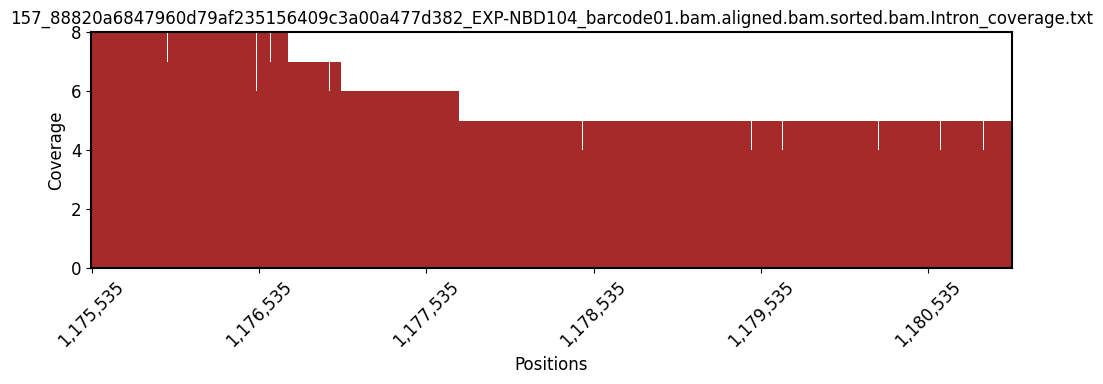

157_88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam.Intron_coverage.txt


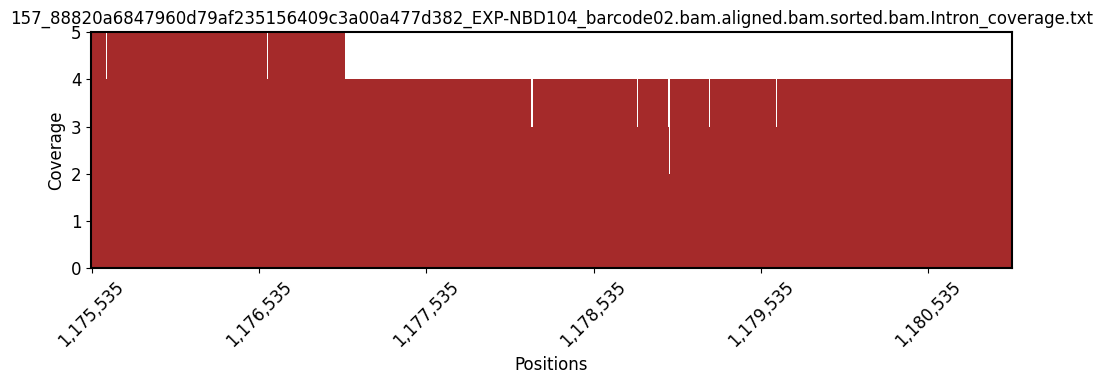

157_88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam.Intron_coverage.txt


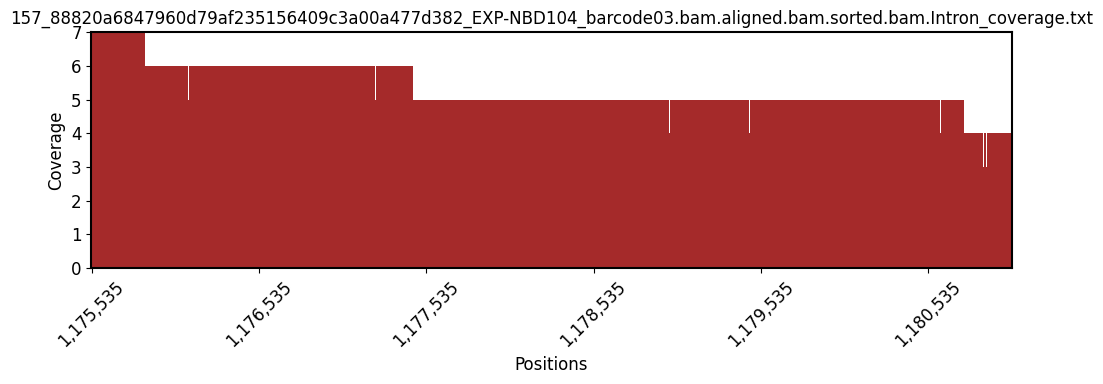

157_88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam.Intron_coverage.txt


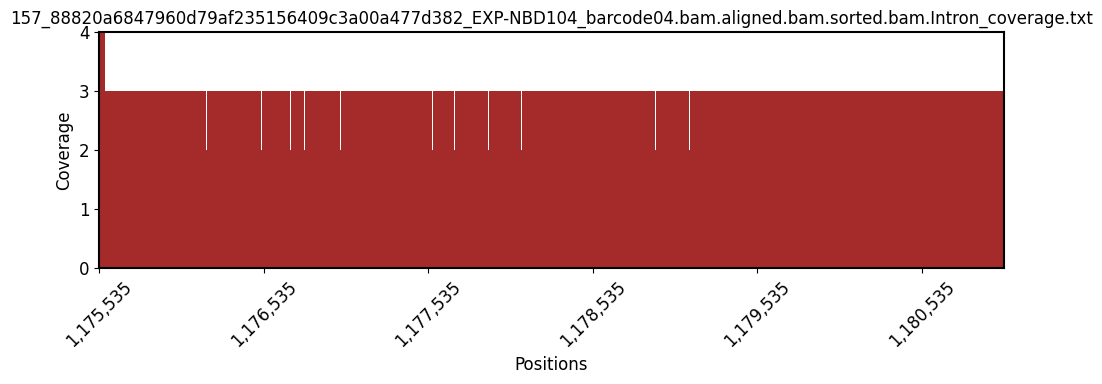

157_88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam.Intron_coverage.txt


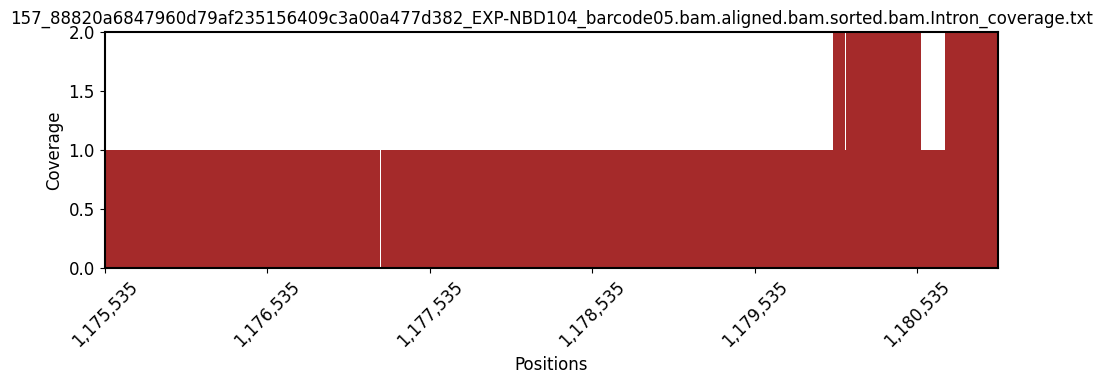

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (5498,) and arg 1 with shape (0,).

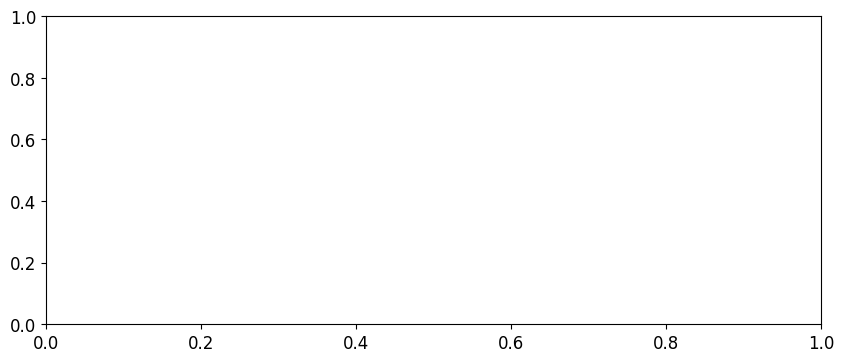

In [24]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/coveragesINTRON.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthIntron(seqLoc2,"157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/"+f,"157_"+f,"157_"+f)

## Methylation

157_LE_hTERT_HFF-1/T2T/hTERT_HFF-1_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


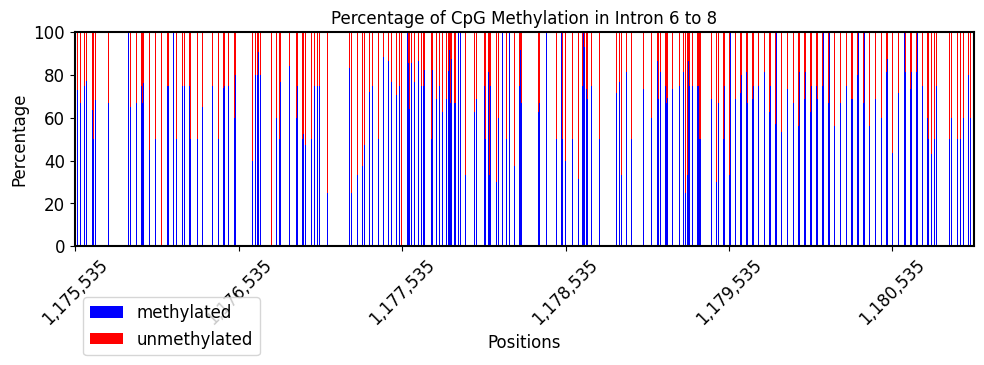

In [32]:
Intron6t8meth("157_LE_hTERT_HFF-1/T2T/hTERT_HFF-1_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
             "157_LE_hTERT_HFF-1_intron")

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam.bed


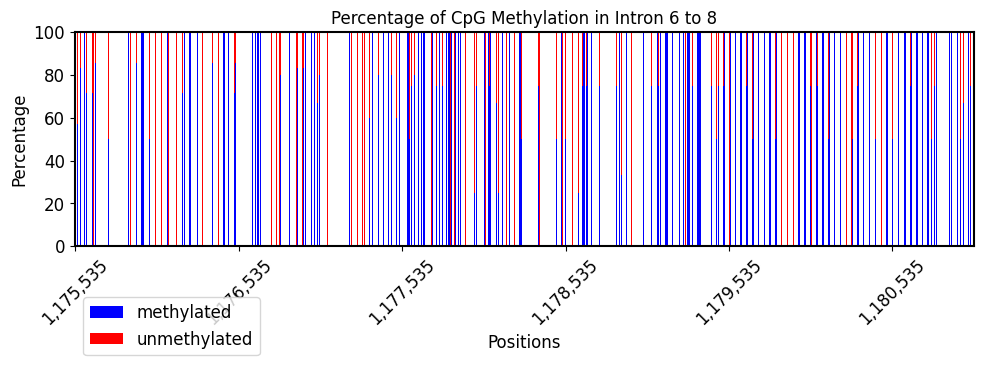

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam.bed


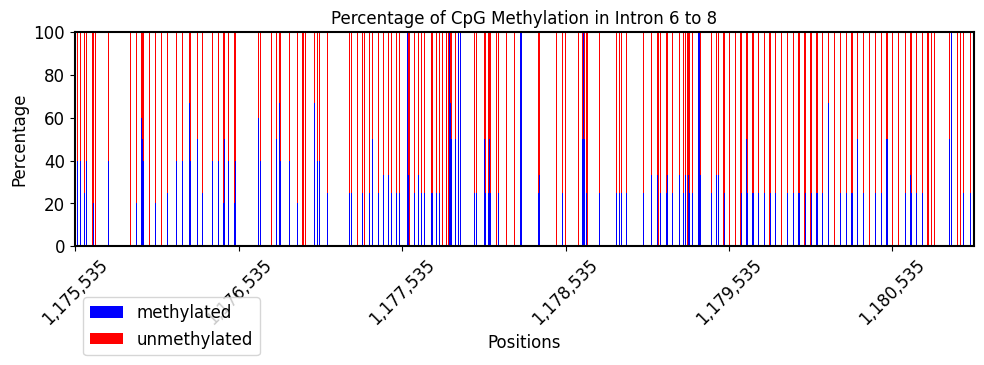

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam.bed


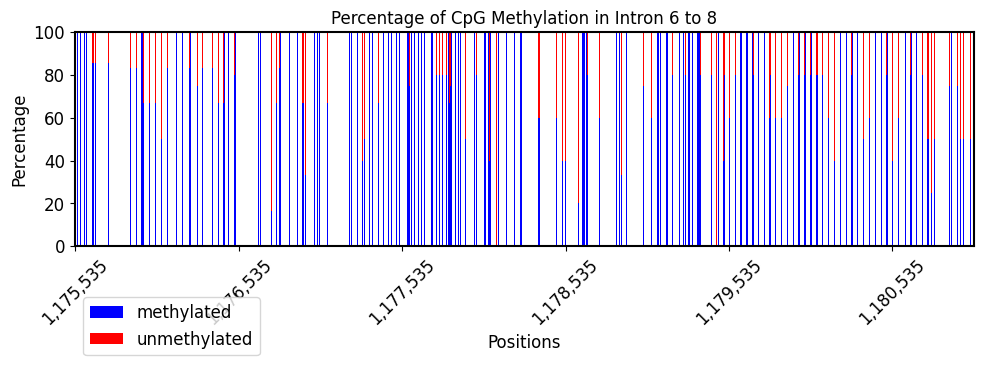

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam.bed


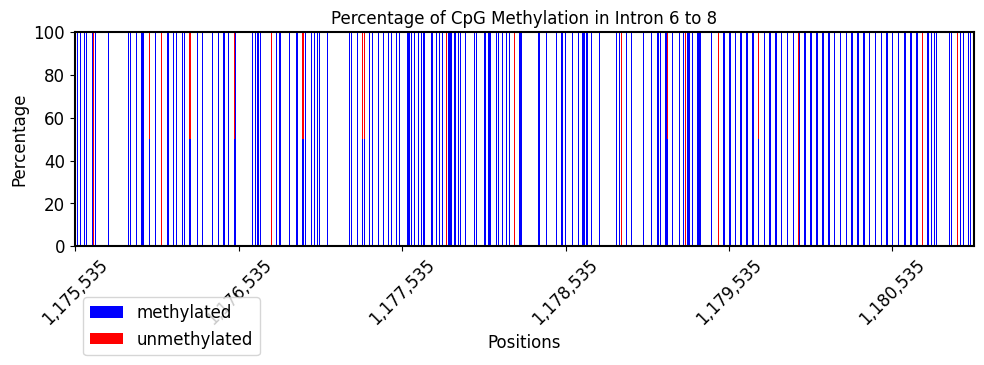

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam.bed


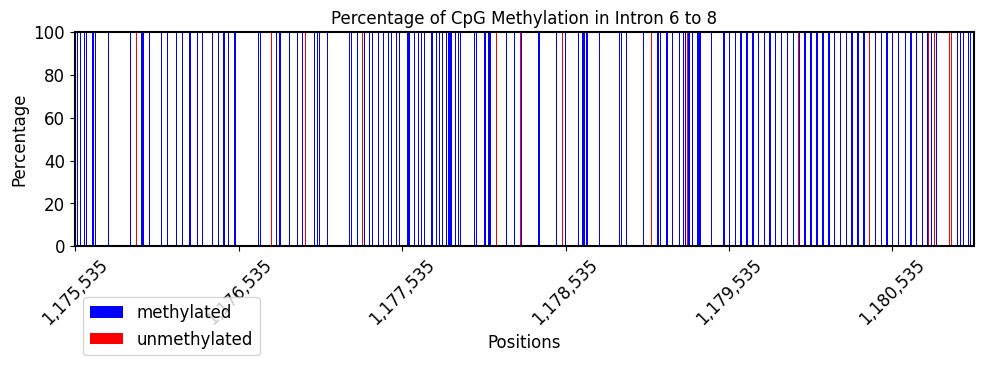

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.bed


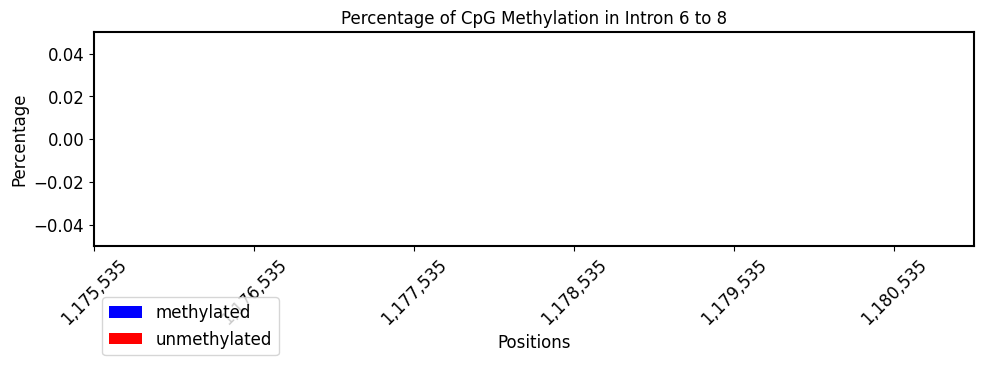

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.bed


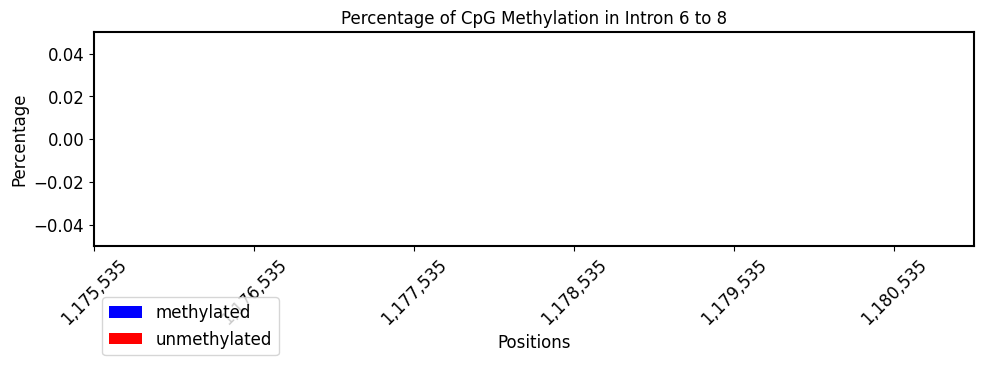

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode08.bam.aligned.bam.sorted.bam.bed


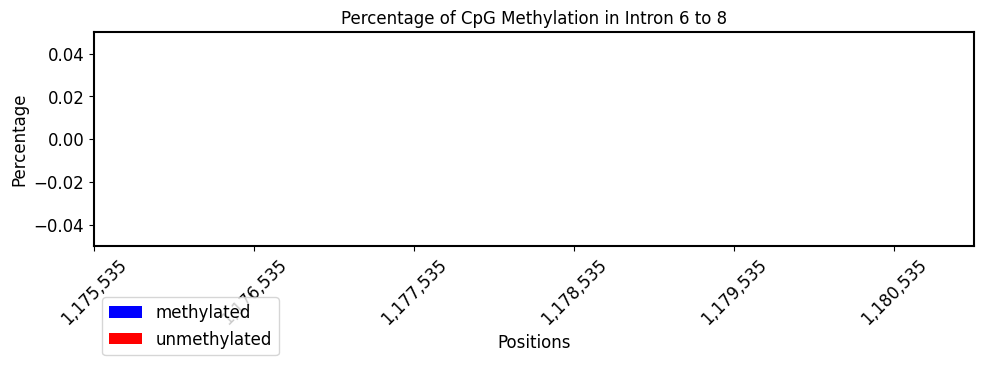

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode09.bam.aligned.bam.sorted.bam.bed


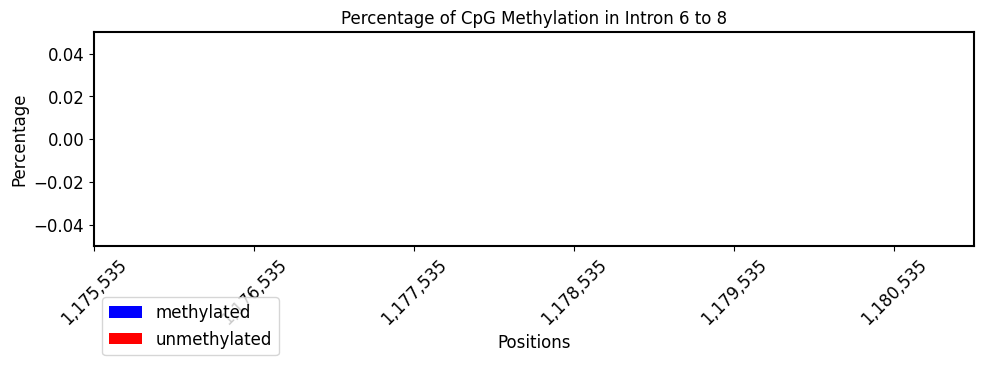

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode10.bam.aligned.bam.sorted.bam.bed


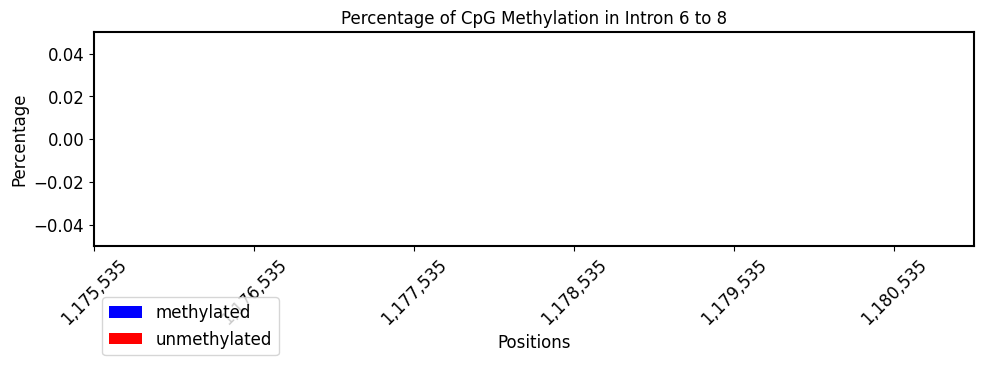

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode11.bam.aligned.bam.sorted.bam.bed


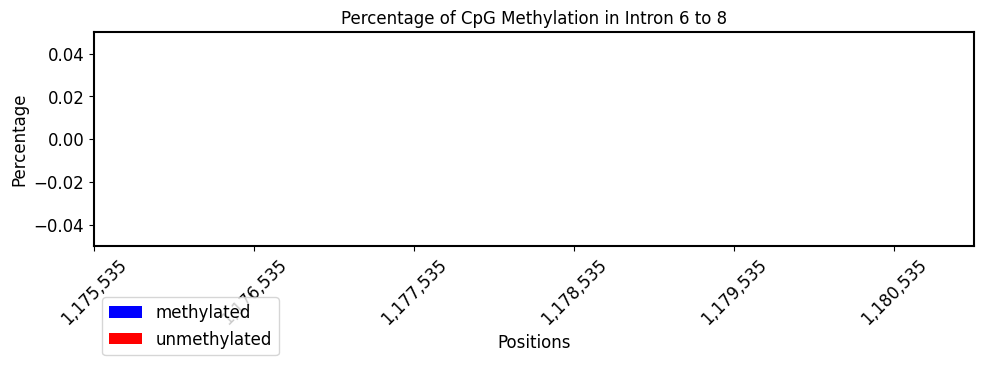

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.bed


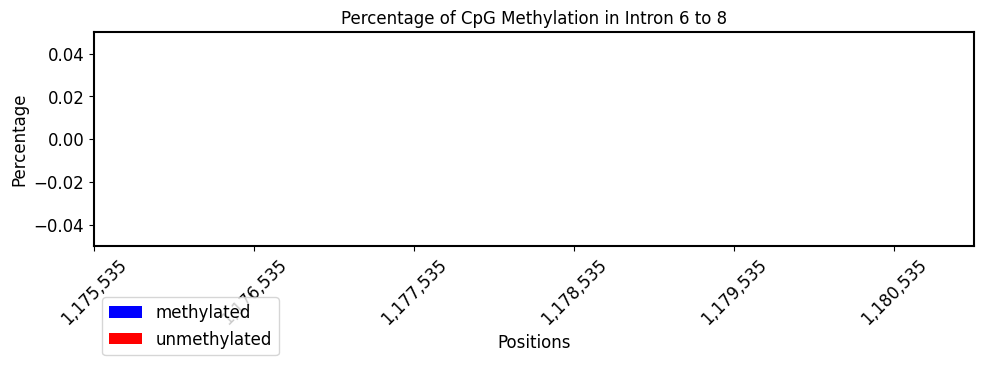

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


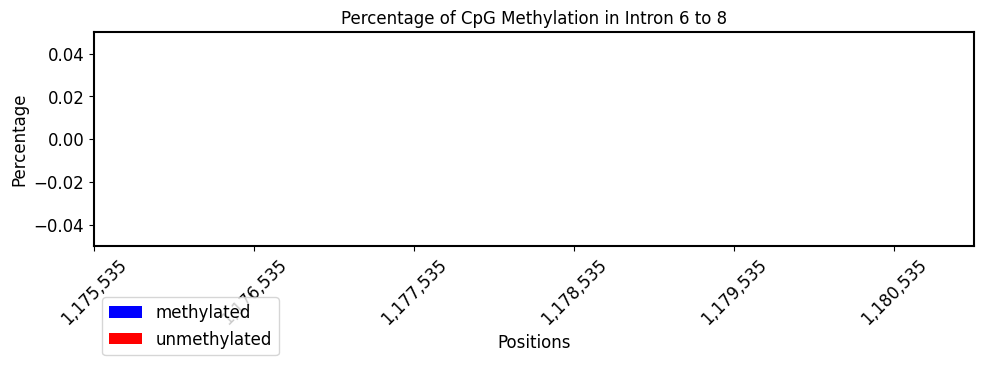

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode14.bam.aligned.bam.sorted.bam.bed


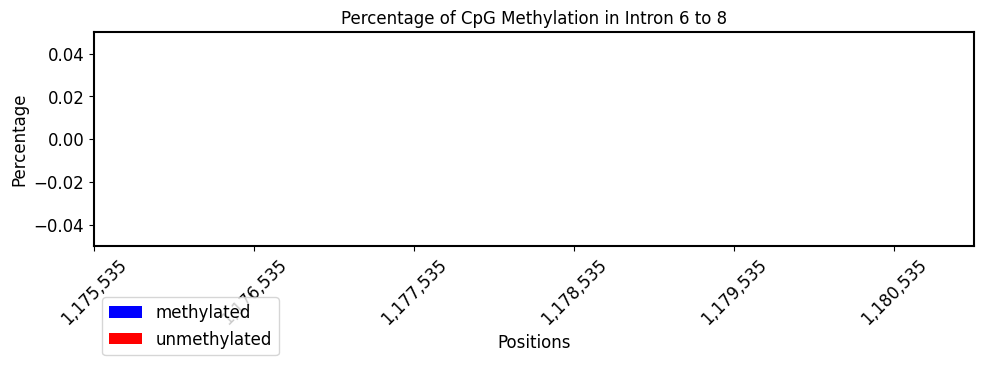

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode15.bam.aligned.bam.sorted.bam.bed


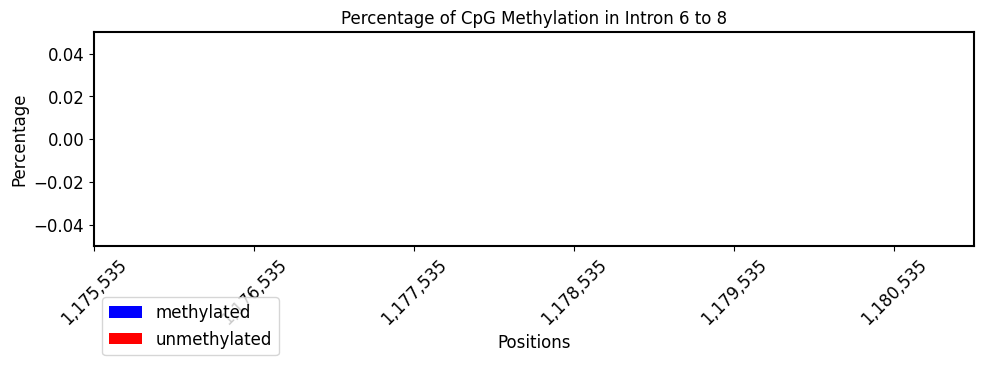

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode17.bam.aligned.bam.sorted.bam.bed


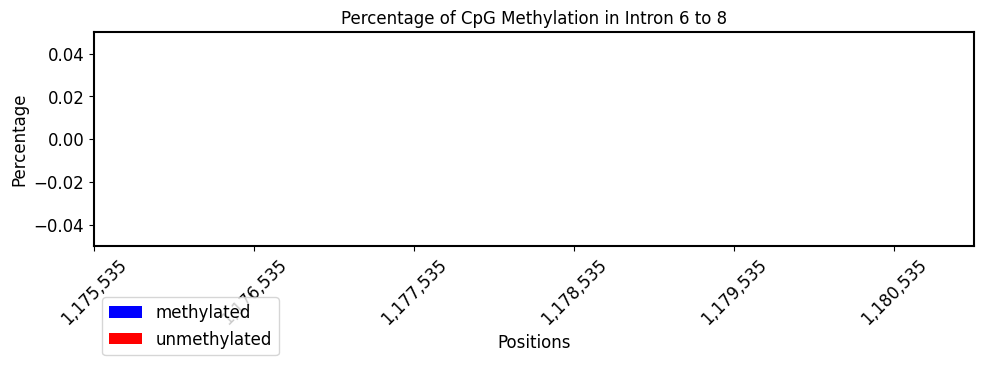

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode18.bam.aligned.bam.sorted.bam.bed


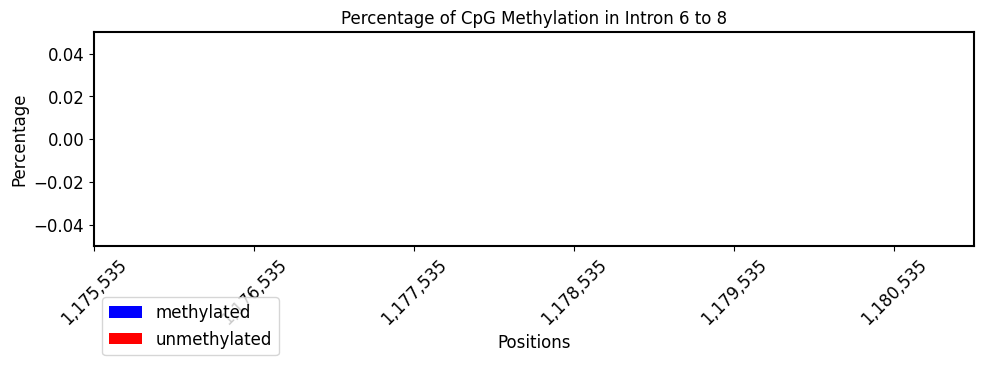

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam.bed


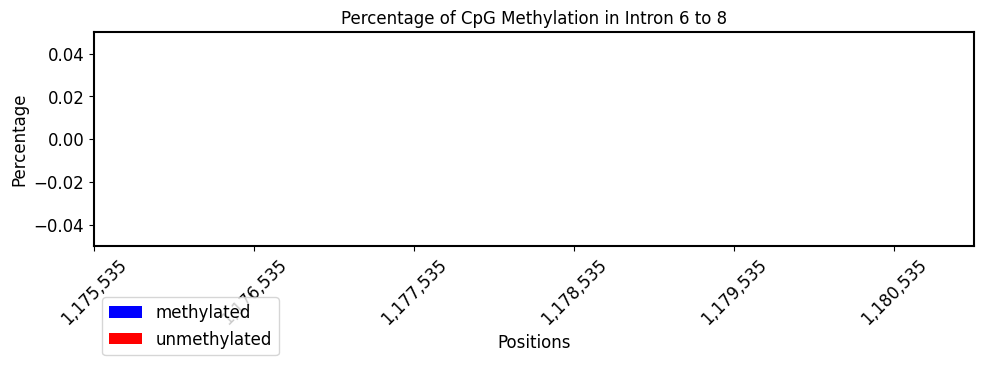

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam.bed


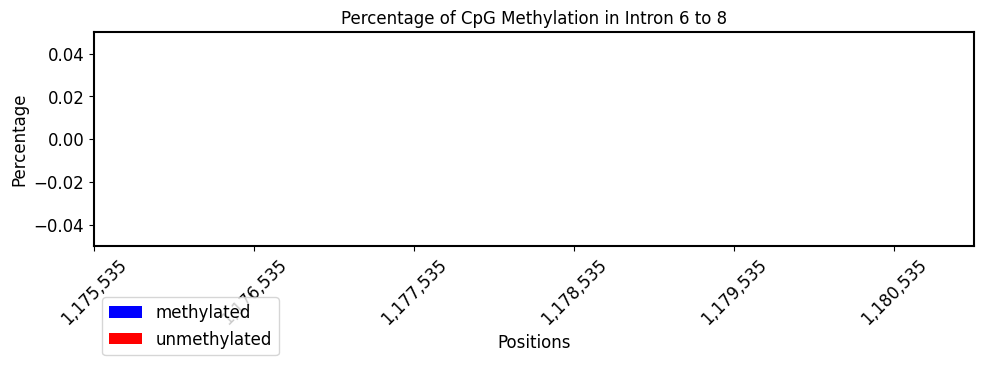

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


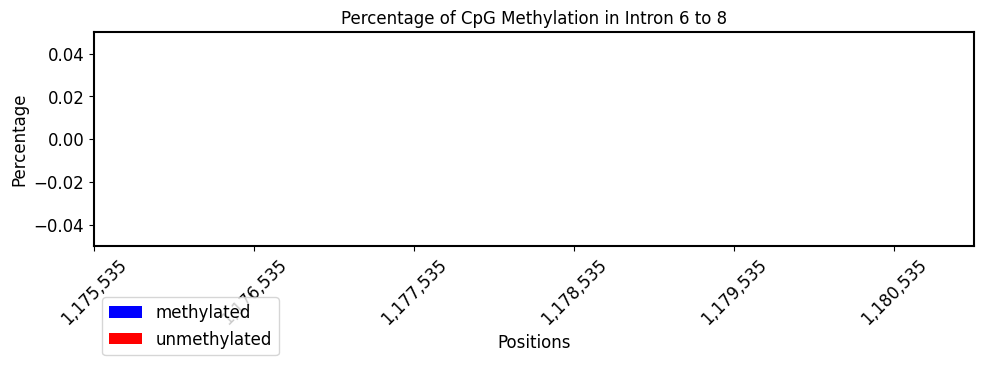

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


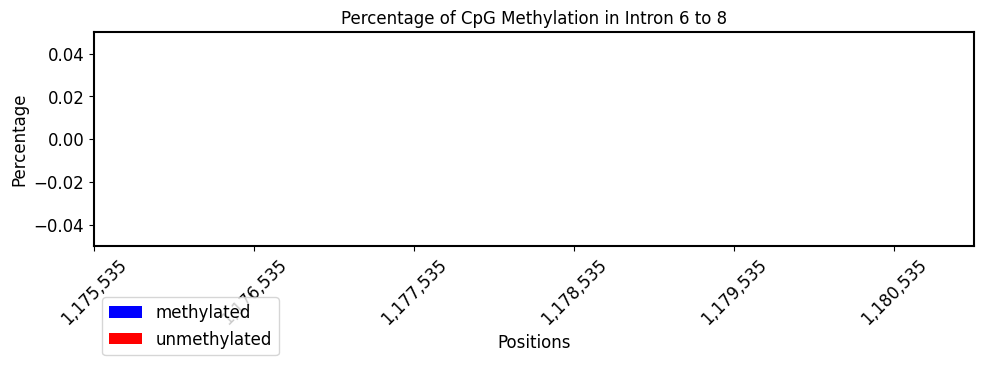

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_unclassified.bam.aligned.bam.sorted.bam.bed


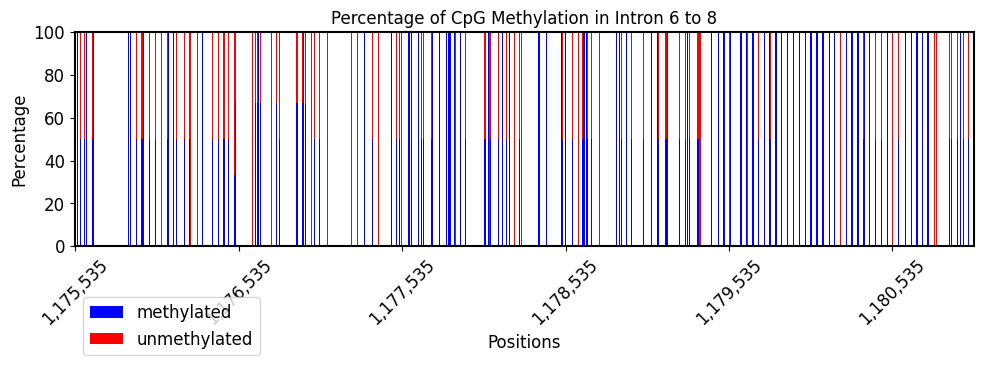

In [33]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    Intron6t8meth("157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/"+f,"157_"+f+"_intron")

## Annotation

/tmp/ipykernel_49182/16471449.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


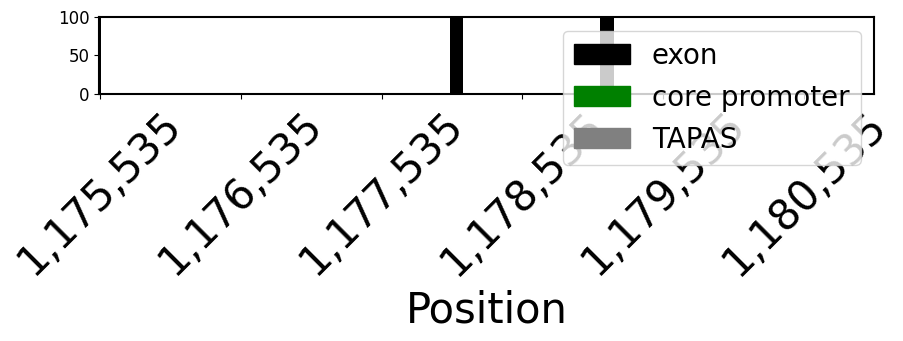

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")
annot = {}
count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        annot[count]=0
file.close()

# Define regions to color-code
for k,v in annot.items():
    if k >=1175535 and k<=1175540:
        annot[k]=100
    elif k >=1178026 and k<=1178110:
        annot[k]=100
    elif k >=1179092 and k<=1179186:
        annot[k]=100

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
black_patch = mpatches.Patch(color='black', label='exon')
green_patch = mpatches.Patch(color='green', label='core promoter')
grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/Intron6to8Annotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()


# TAPAS

## Coverage

In [9]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

realigned.bam.sorted.bam
Average depth: 2.92388
Standard deviation: 1.32103
10
6


In [12]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX_FILTERED/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam
Average depth: 1.57936
Standard deviation: 0.523593
2
2
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam
Average depth: 0.957733
Standard deviation: 0.201198
1
1
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
Average depth: 0.982383
Standard deviation: 0.131556
1
1
0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam
Average depth: 1
Standard deviation: 0
5
1
0c4438981973aa8e80d5289c6af523d9def8fb8d_unclassified.bam.aligned.bam.sorted.bam
Average depth: 2.92388
Standard deviation: 1.32103
10
6


In [13]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX_FILTERED
for f in *.bam.aligned.bam.sorted.bam; 
do samtools depth -a -b /media/data_01/vapatter/PROJECTS/15-LARS/125_NDLE_hTERT_CRISPR_VA13/T2T/locations2.bed \
$f > $f.hTAPAS_coverage.txt; done
ls *$f.hTAPAS_coverage.txt > coveragesTAPAS.txt

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


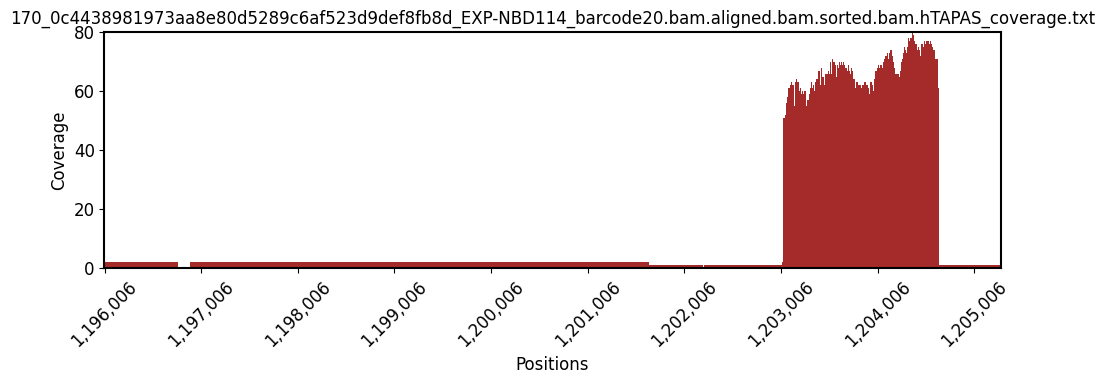

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


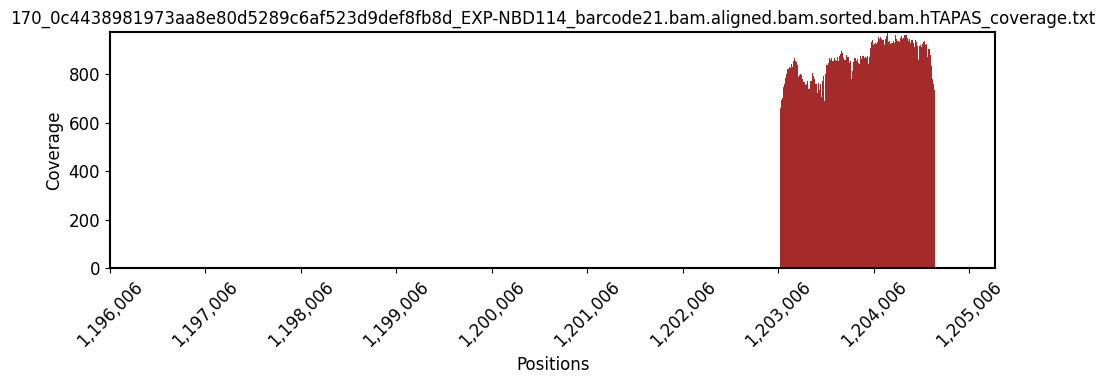

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


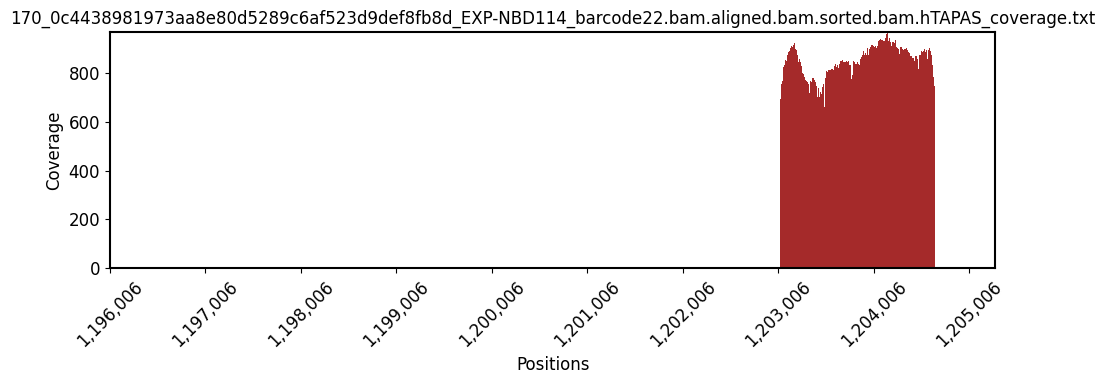

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode23.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


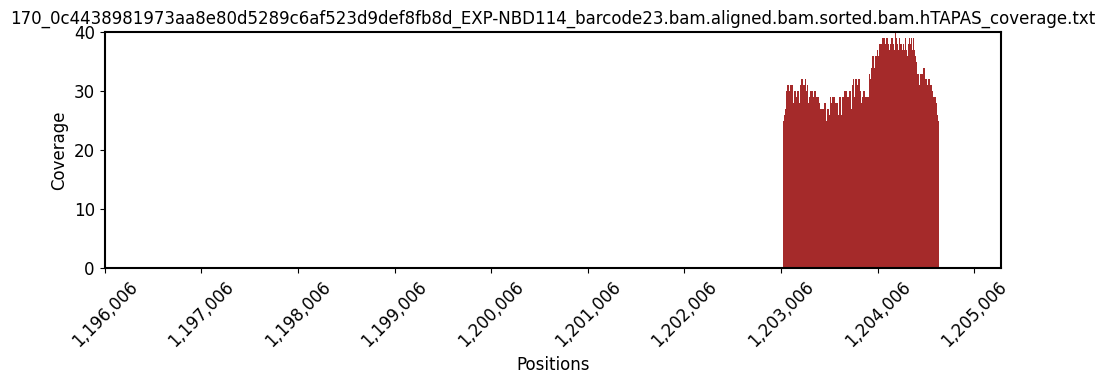

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


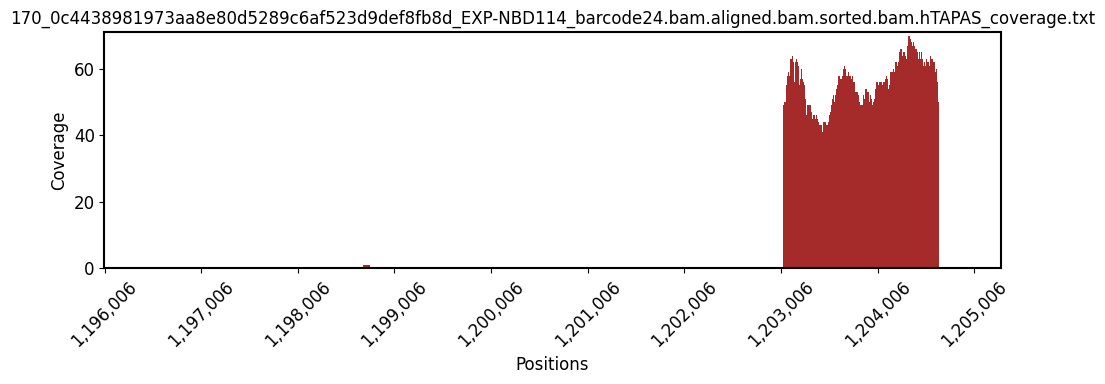

170_0c4438981973aa8e80d5289c6af523d9def8fb8d_unclassified.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


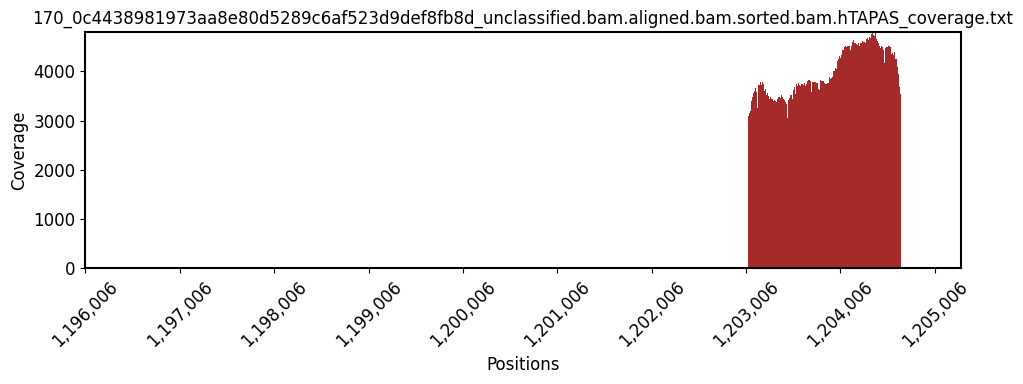

In [17]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX/coveragesTAPAS.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthTAPAS(seqLoc2,"170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX/"+f,"170_"+f,"170_"+f)

170_filt_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


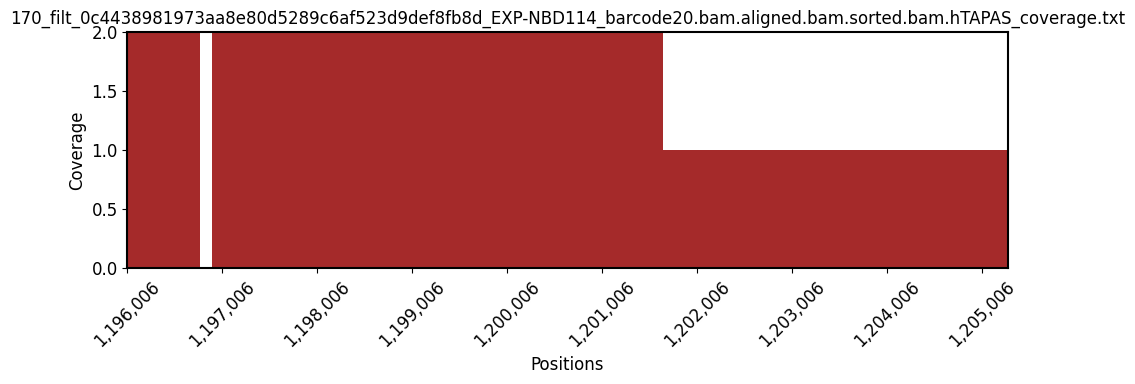

170_filt_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


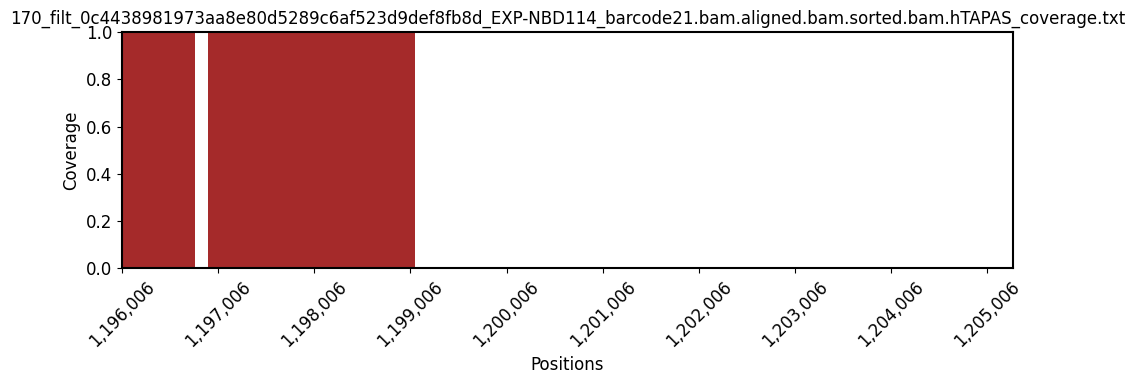

170_filt_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


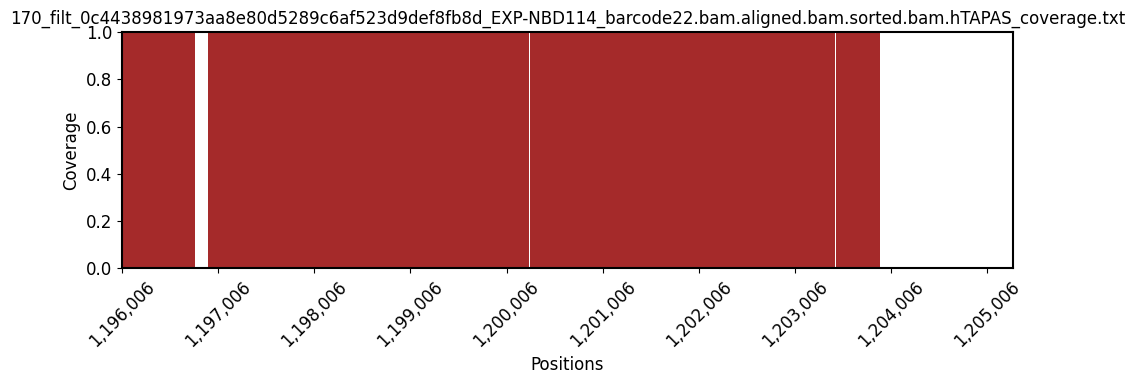

170_filt_0c4438981973aa8e80d5289c6af523d9def8fb8d_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


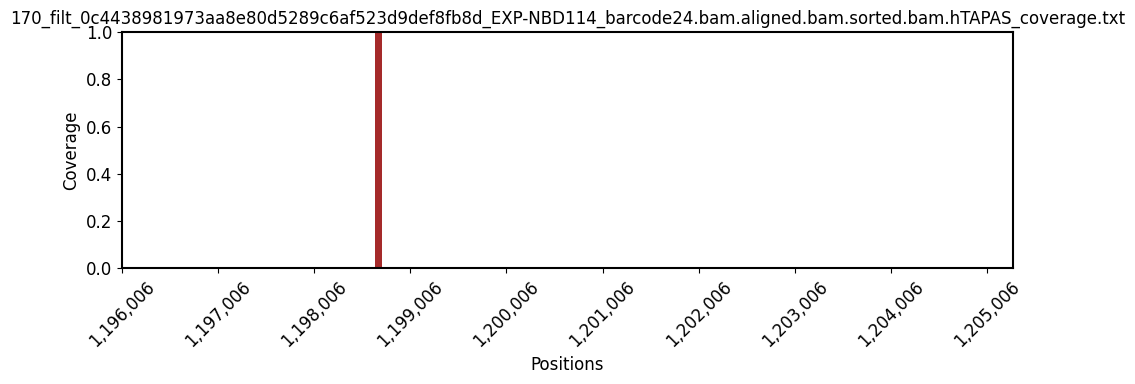

170_filt_0c4438981973aa8e80d5289c6af523d9def8fb8d_unclassified.bam.aligned.bam.sorted.bam.hTAPAS_coverage.txt


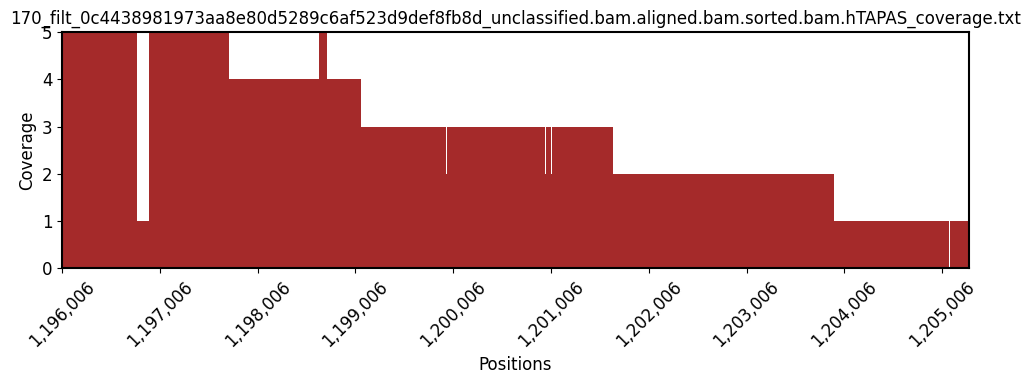

In [18]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX_FILTERED/coveragesTAPAS.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthTAPAS(seqLoc2,"170_LE_hTERT_sheared_DNA/T2T/DORADO_DEMUX_FILTERED/"+f,"170_filt_"+f,"170_filt_"+f)

## Methylation

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam.bed


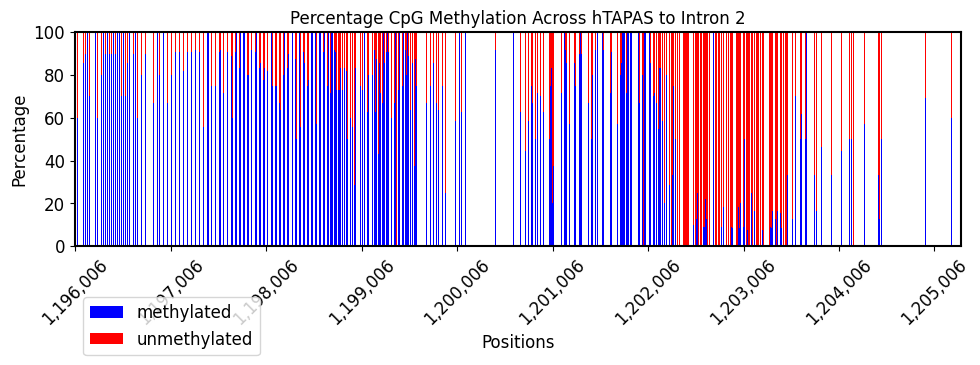

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam.bed


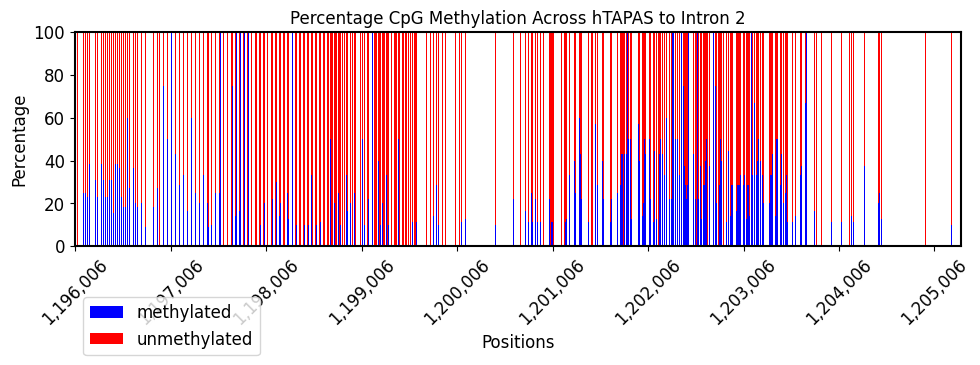

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam.bed


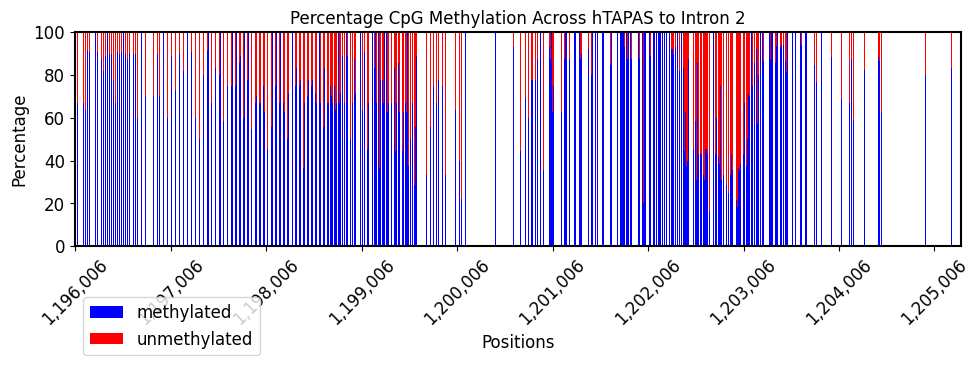

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam.bed


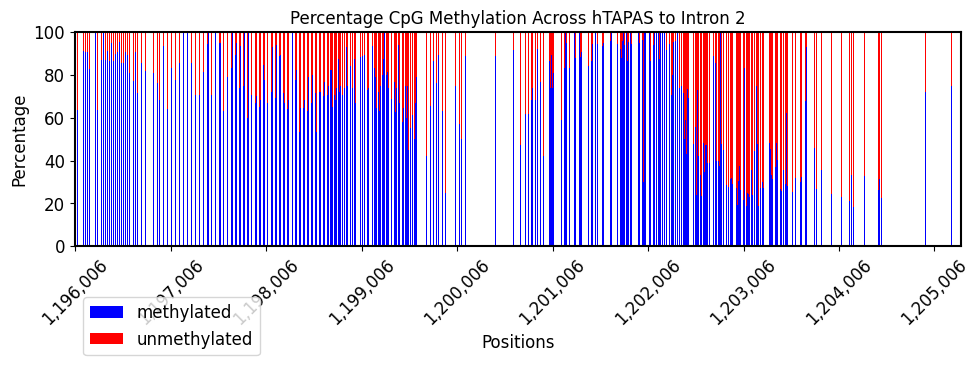

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam.bed


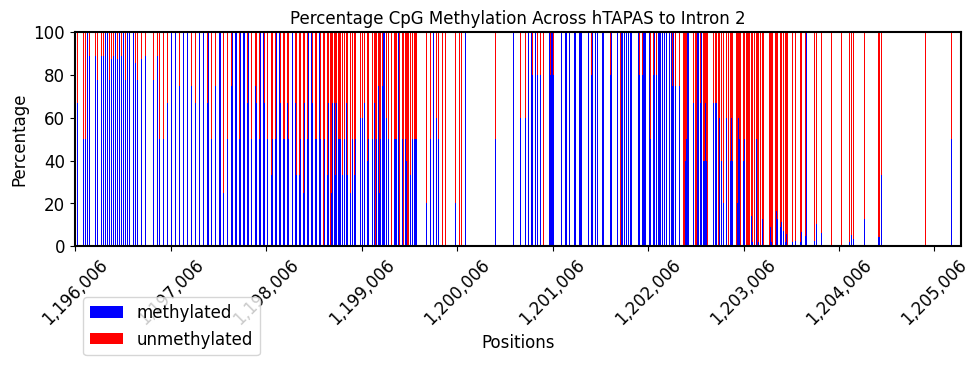

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.bed


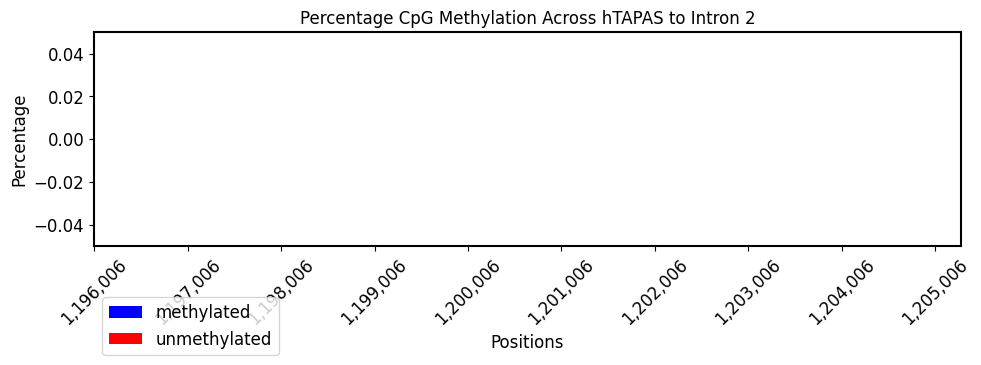

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.bed


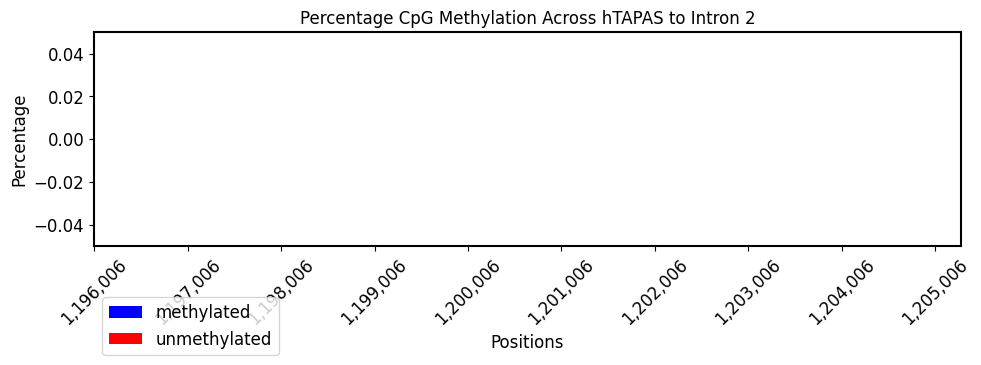

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode08.bam.aligned.bam.sorted.bam.bed


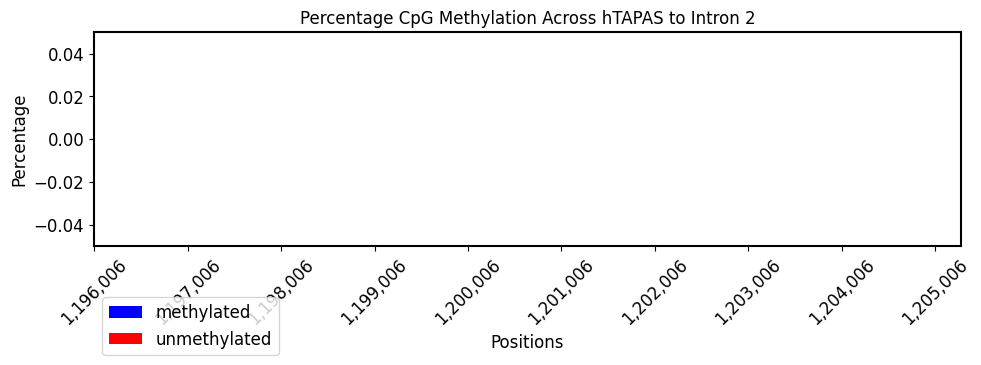

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode09.bam.aligned.bam.sorted.bam.bed


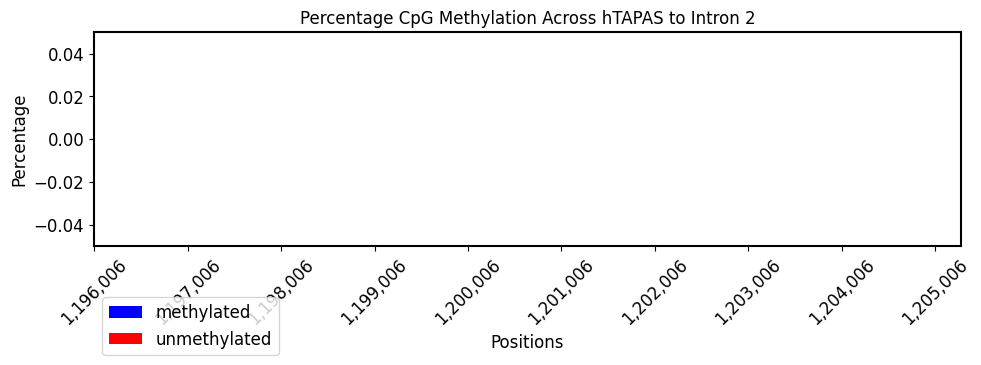

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode10.bam.aligned.bam.sorted.bam.bed


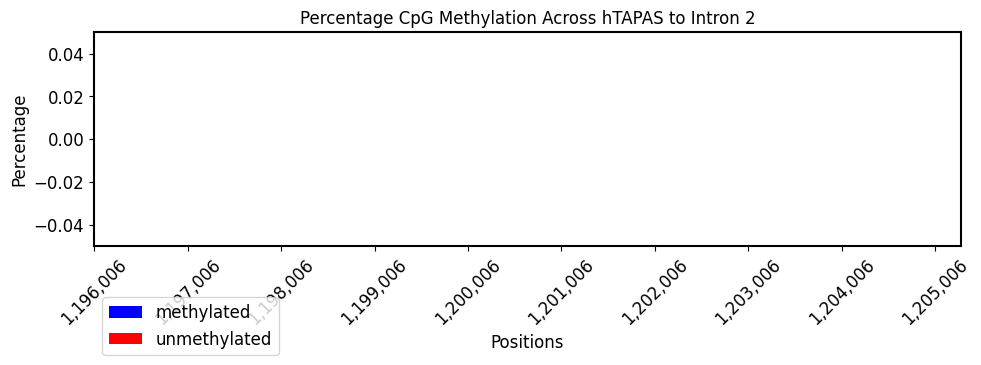

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode11.bam.aligned.bam.sorted.bam.bed


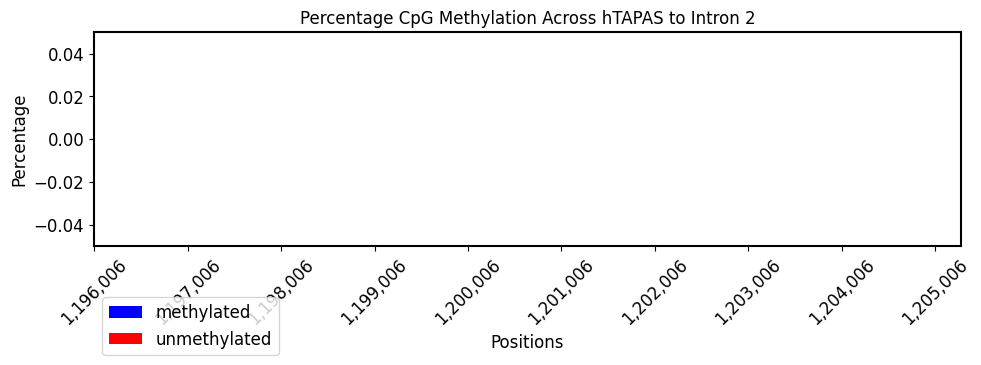

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.bed


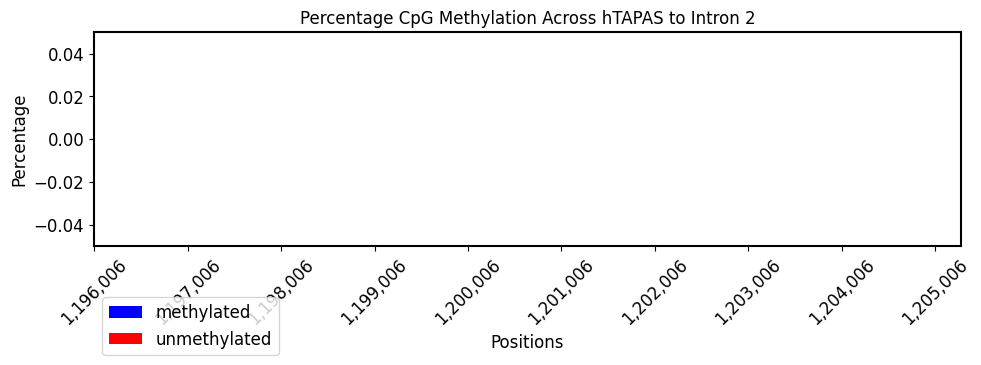

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


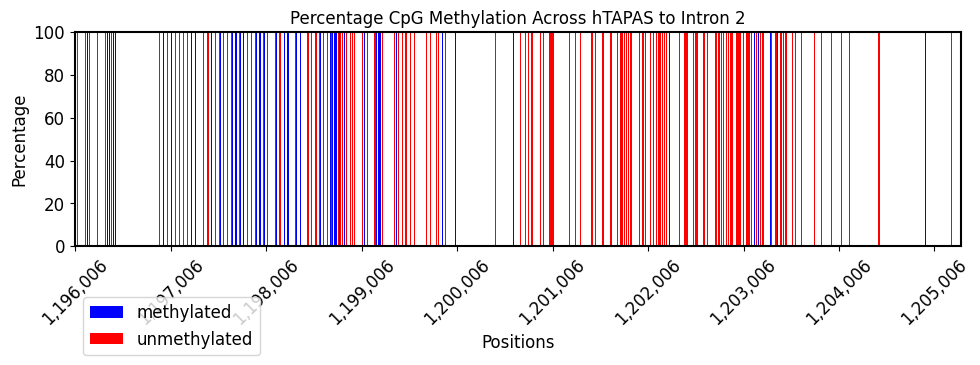

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode14.bam.aligned.bam.sorted.bam.bed


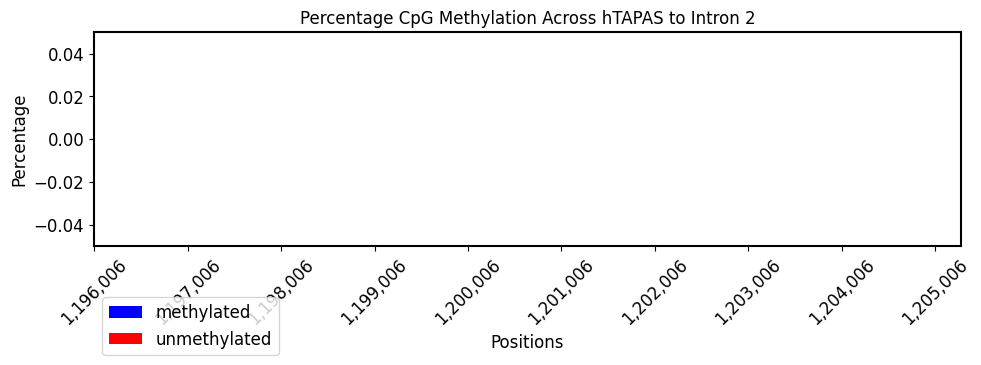

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode15.bam.aligned.bam.sorted.bam.bed


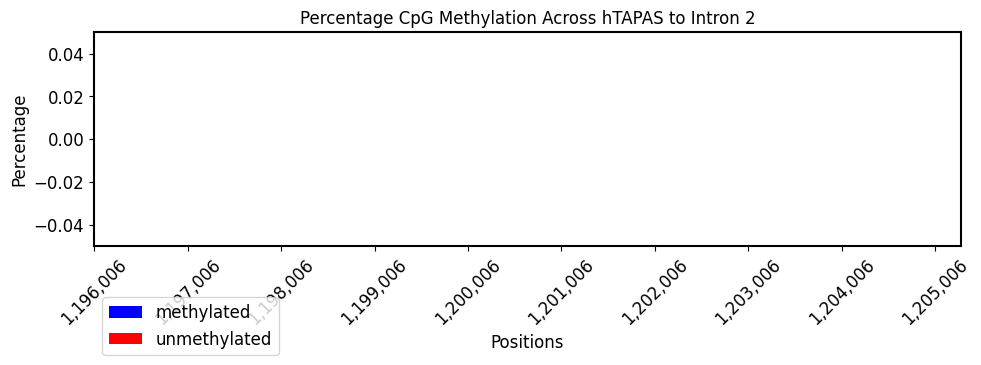

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode17.bam.aligned.bam.sorted.bam.bed


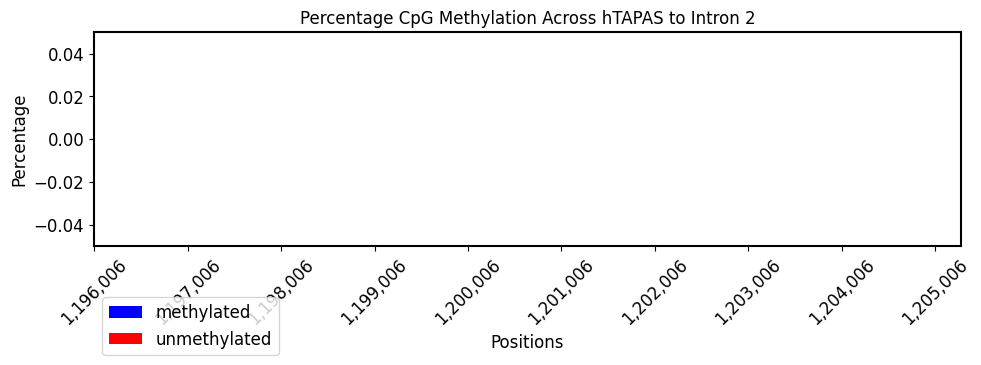

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode18.bam.aligned.bam.sorted.bam.bed


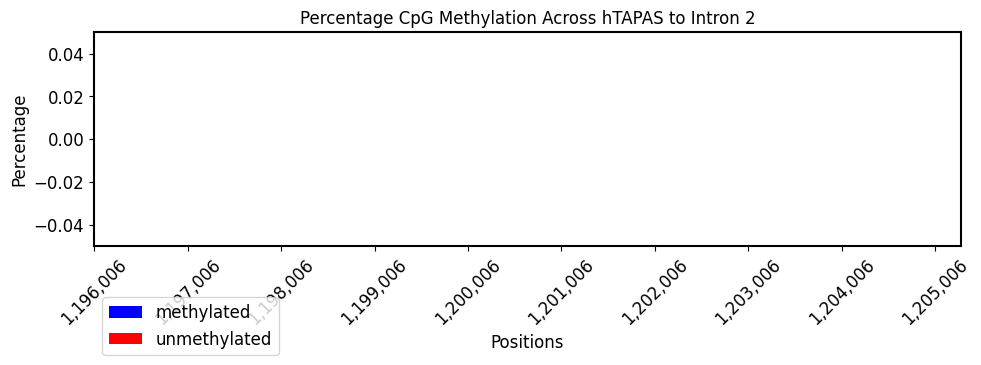

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam.bed


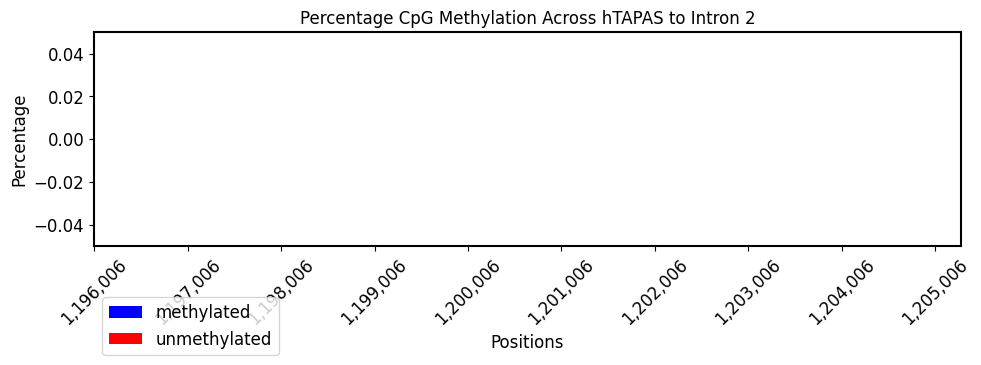

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam.bed


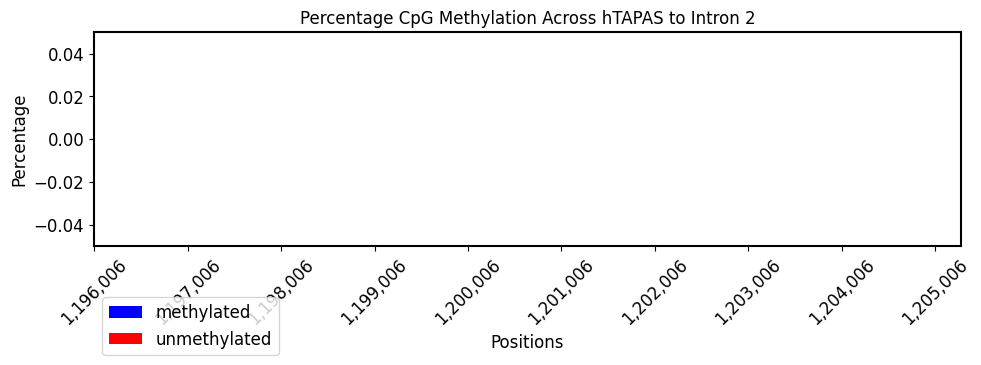

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


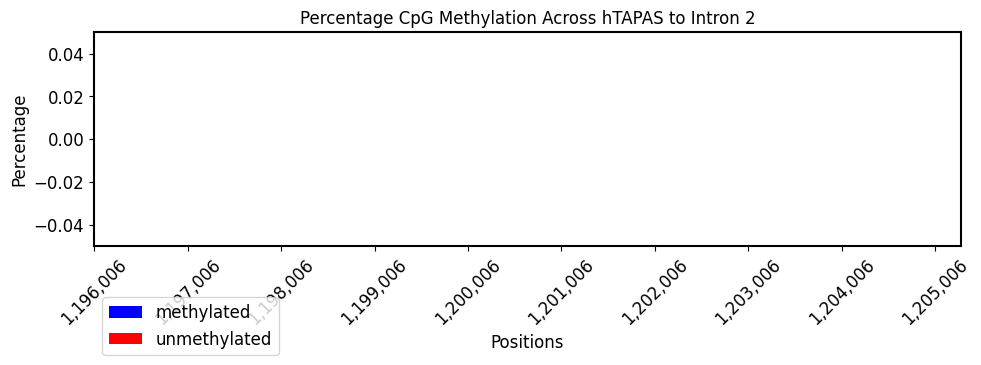

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


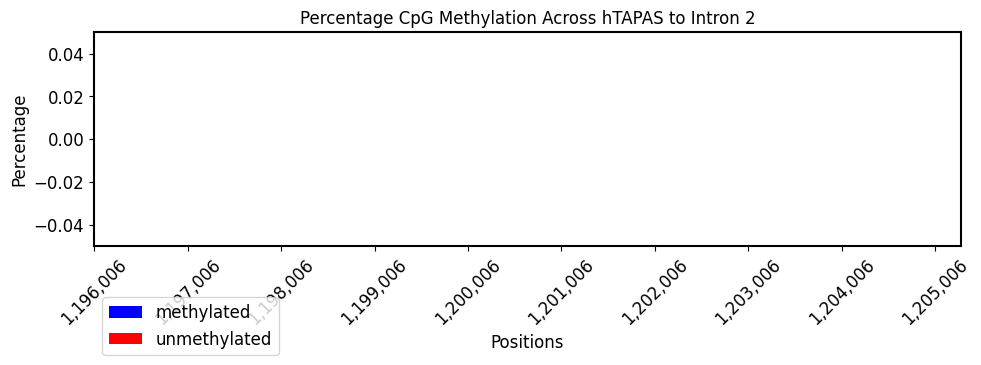

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_unclassified.bam.aligned.bam.sorted.bam.bed


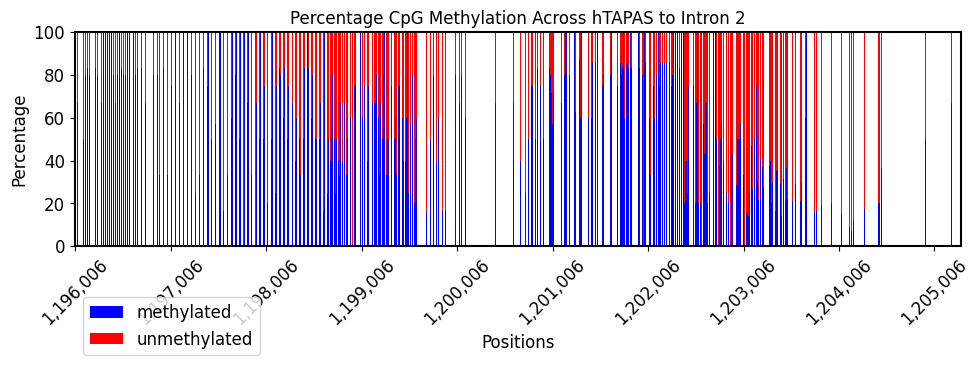

In [34]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/"+f,"157_"+f+"_hTAPAS")

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam.bed


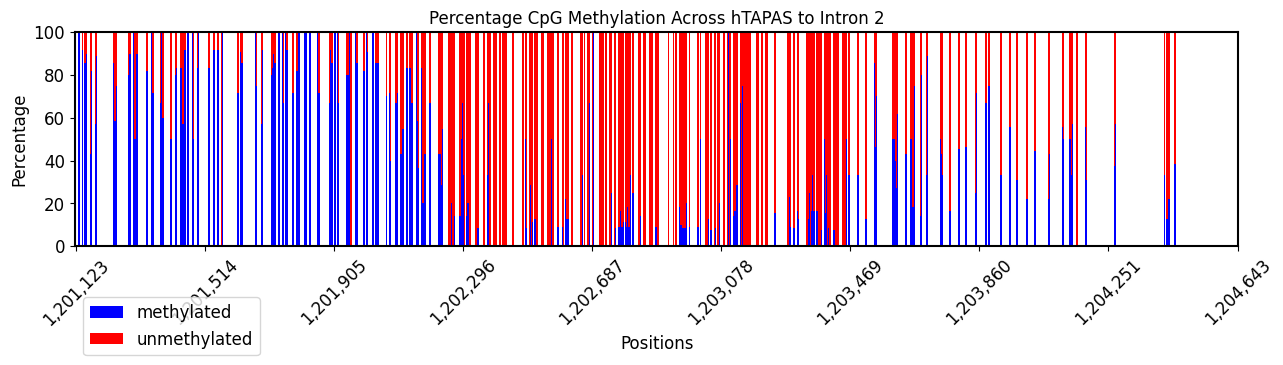

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam.bed


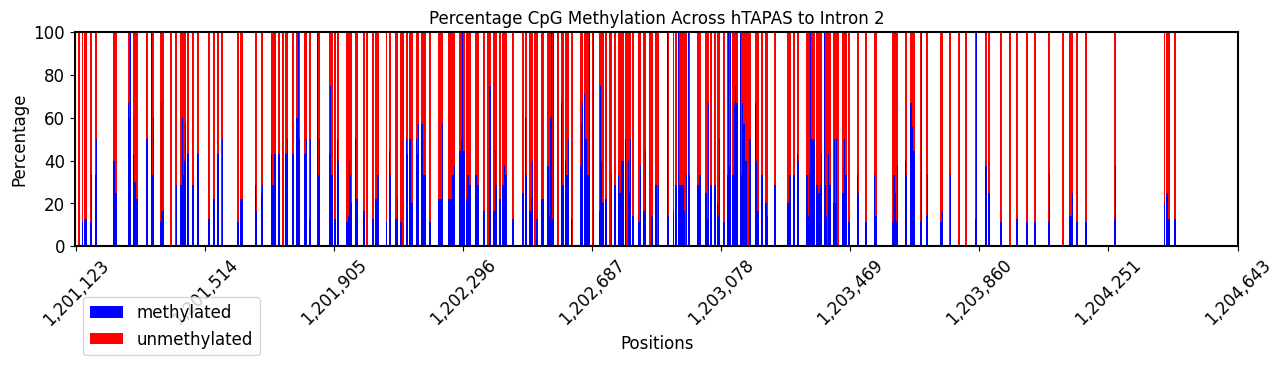

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam.bed


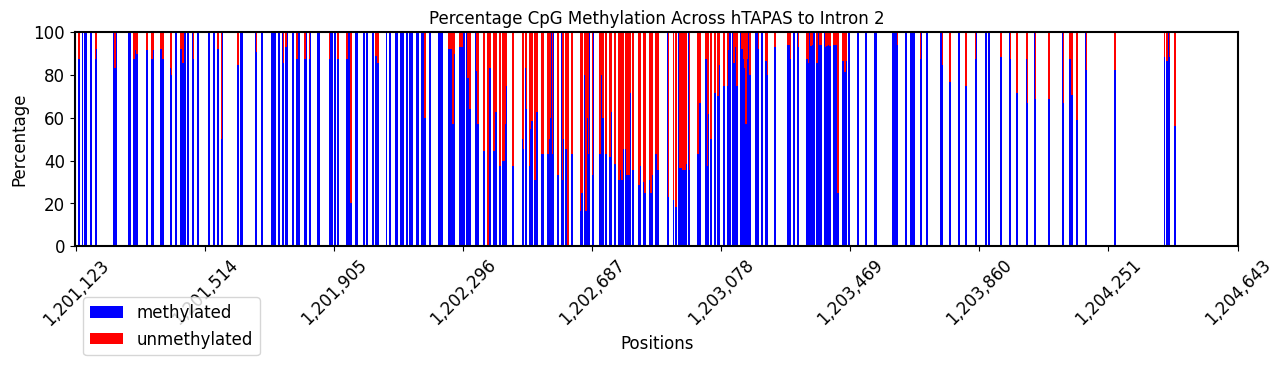

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam.bed


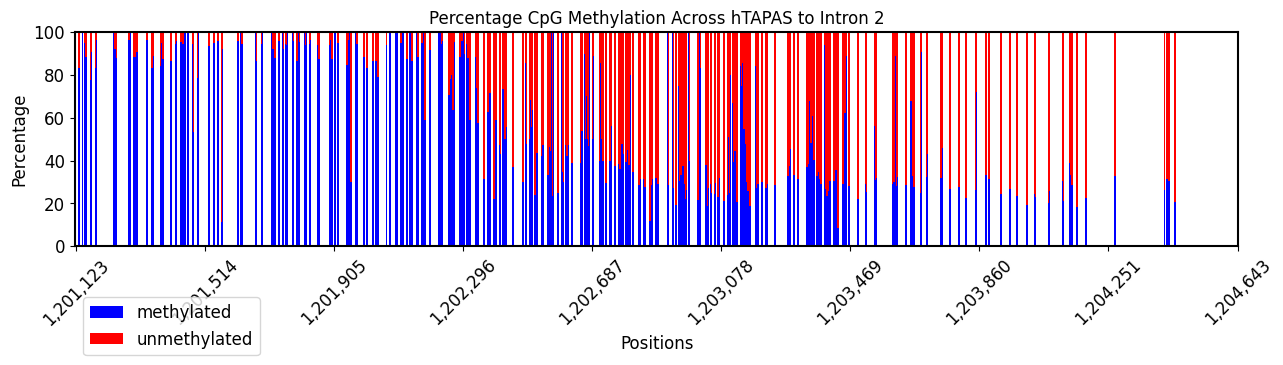

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam.bed


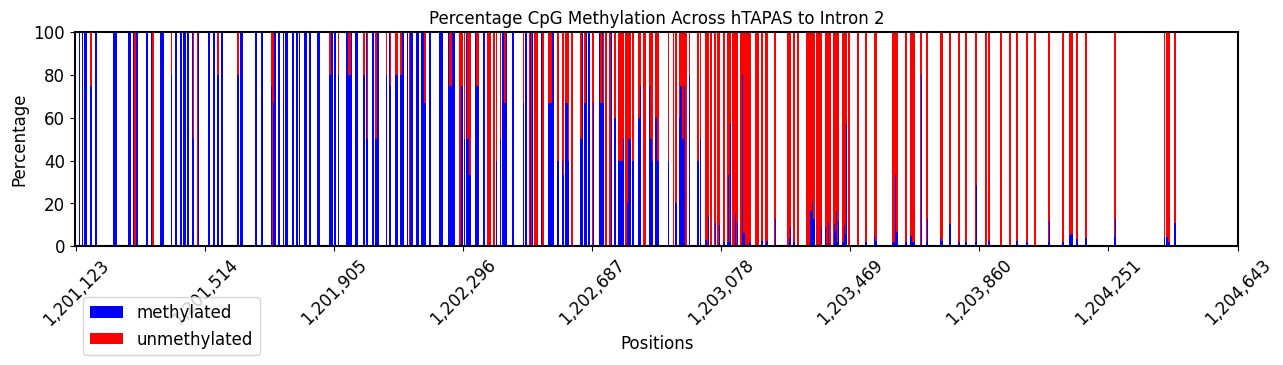

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode06.bam.aligned.bam.sorted.bam.bed


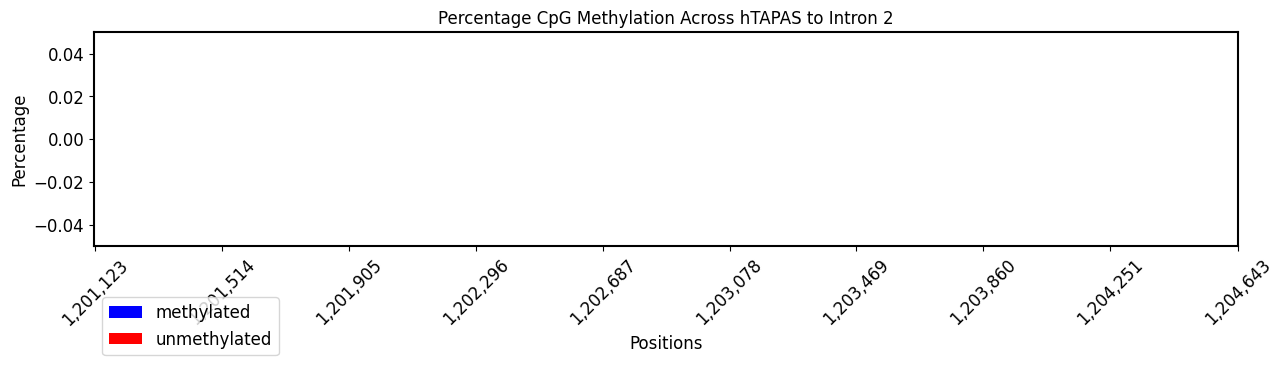

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode07.bam.aligned.bam.sorted.bam.bed


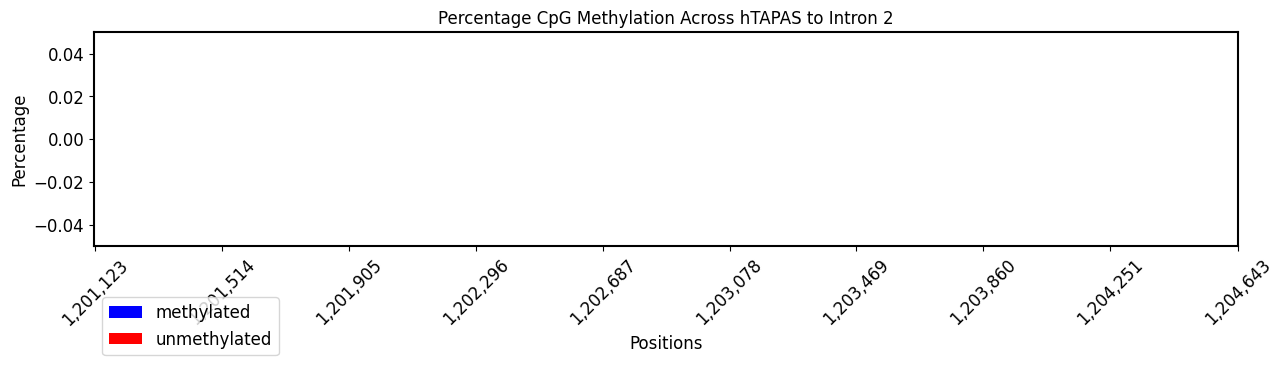

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode08.bam.aligned.bam.sorted.bam.bed


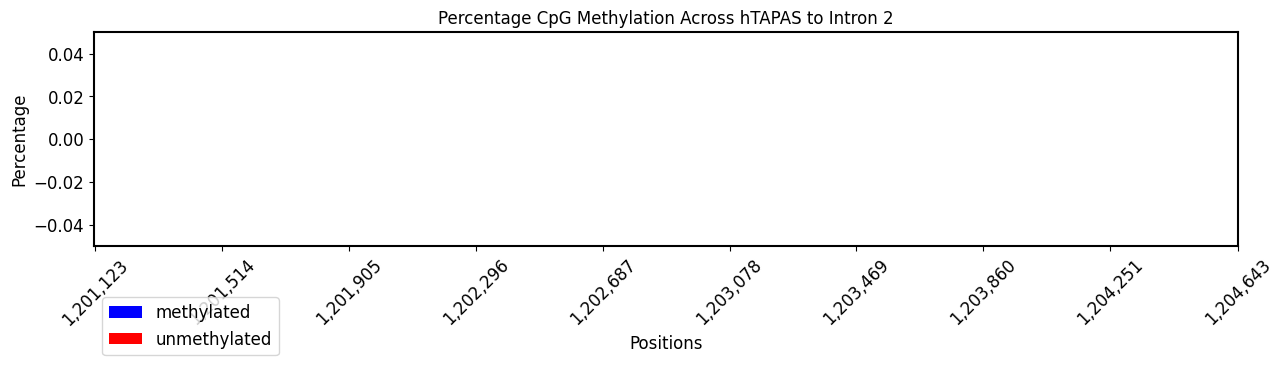

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode09.bam.aligned.bam.sorted.bam.bed


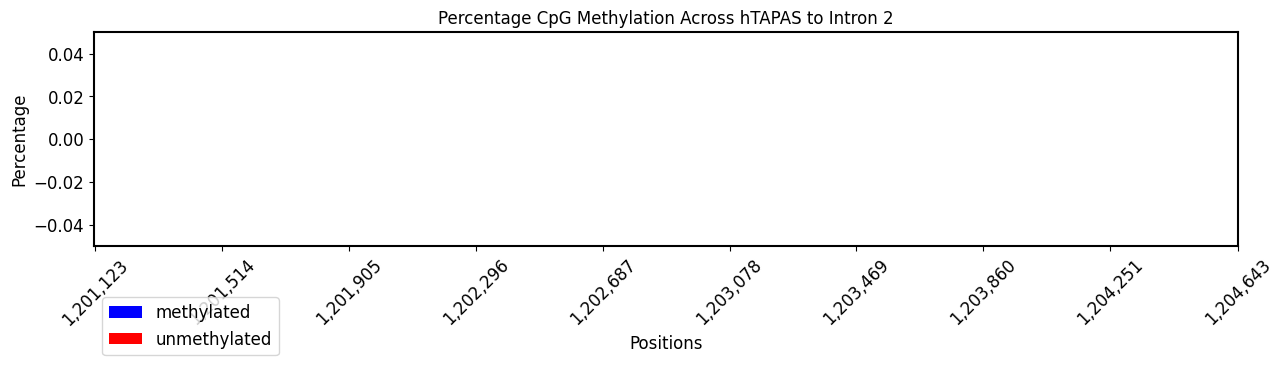

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode10.bam.aligned.bam.sorted.bam.bed


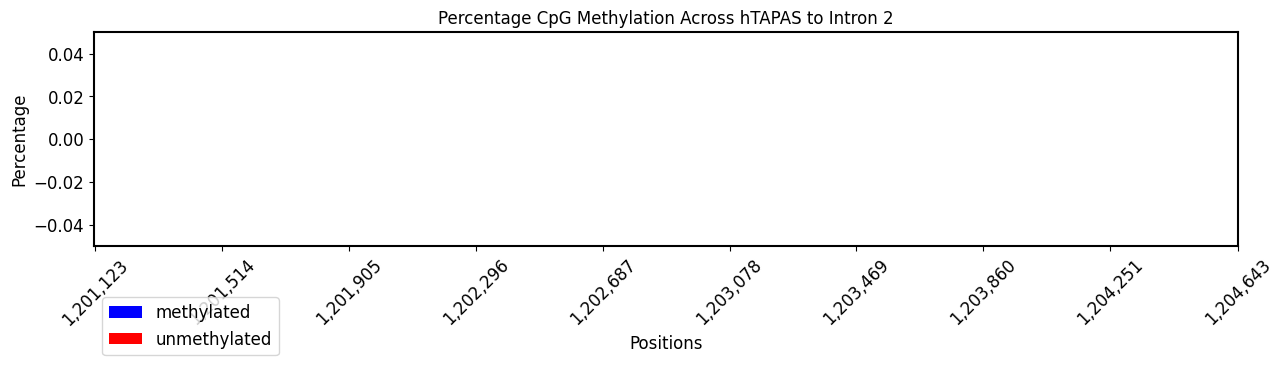

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode11.bam.aligned.bam.sorted.bam.bed


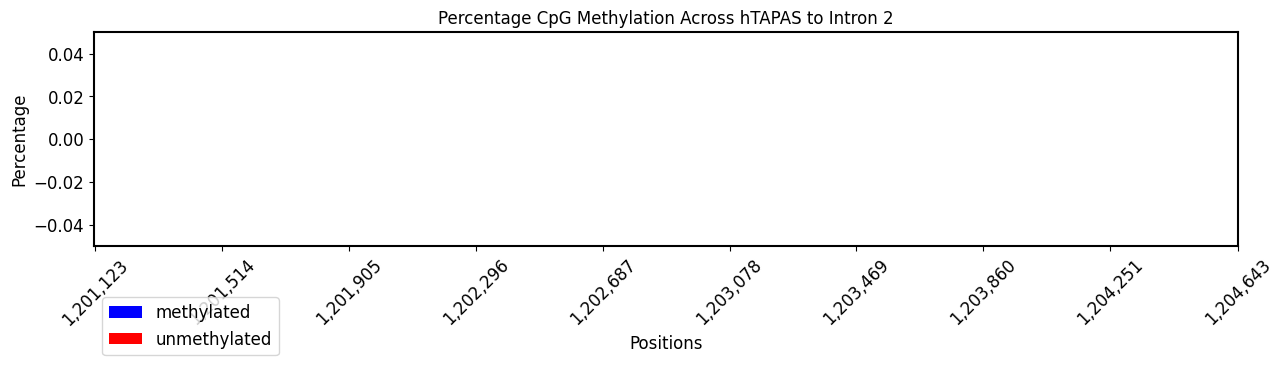

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD104_barcode12.bam.aligned.bam.sorted.bam.bed


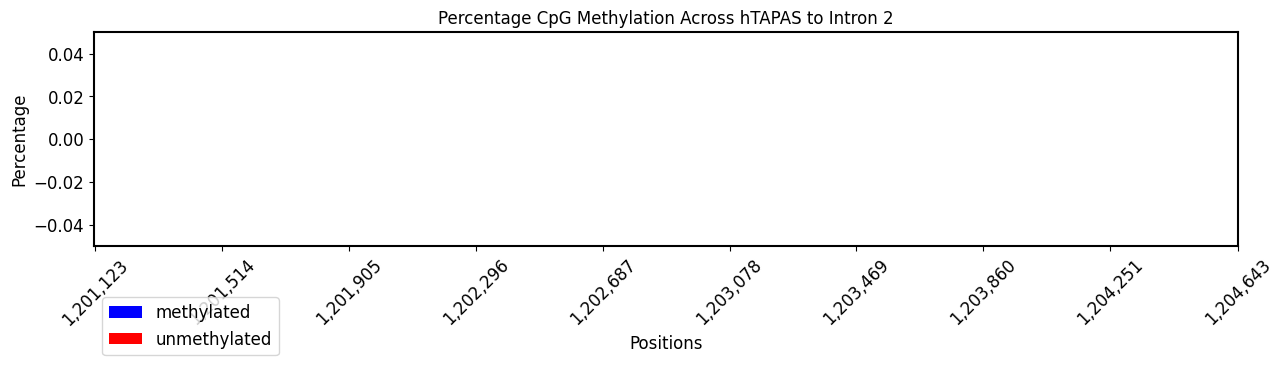

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


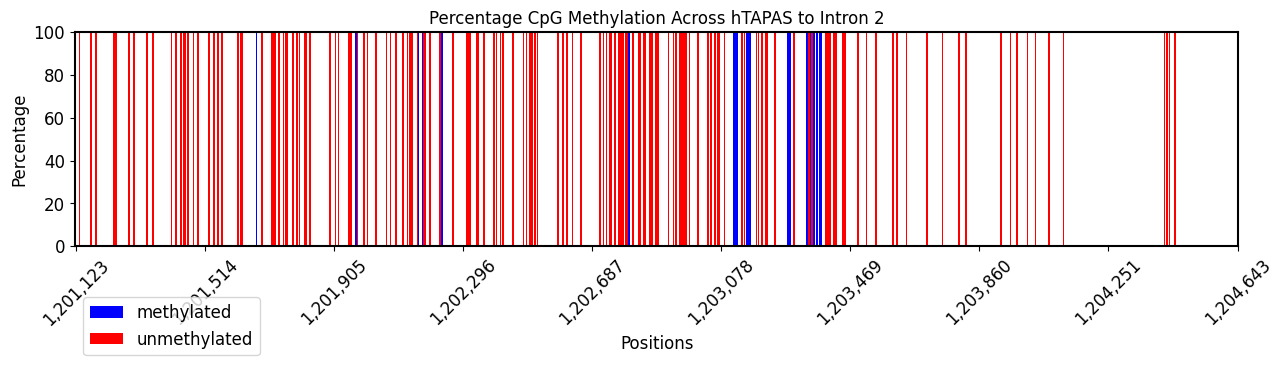

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode14.bam.aligned.bam.sorted.bam.bed


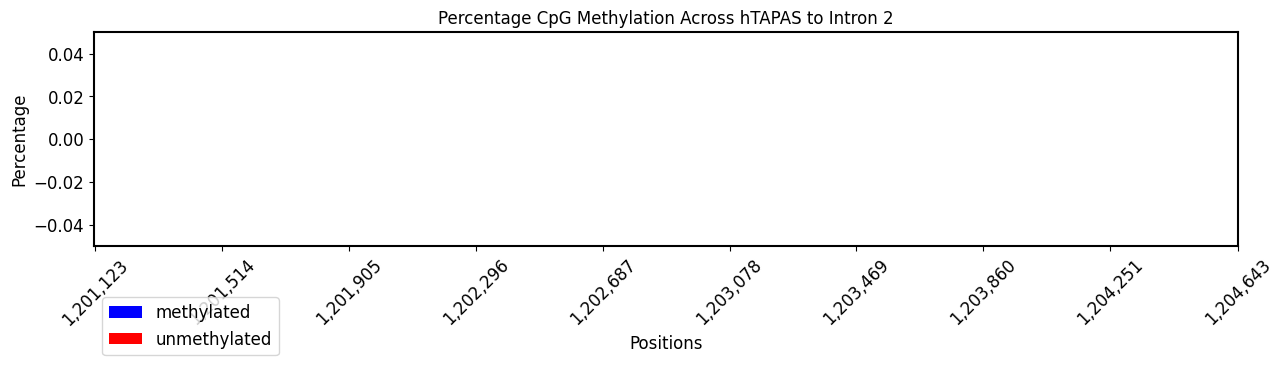

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode15.bam.aligned.bam.sorted.bam.bed


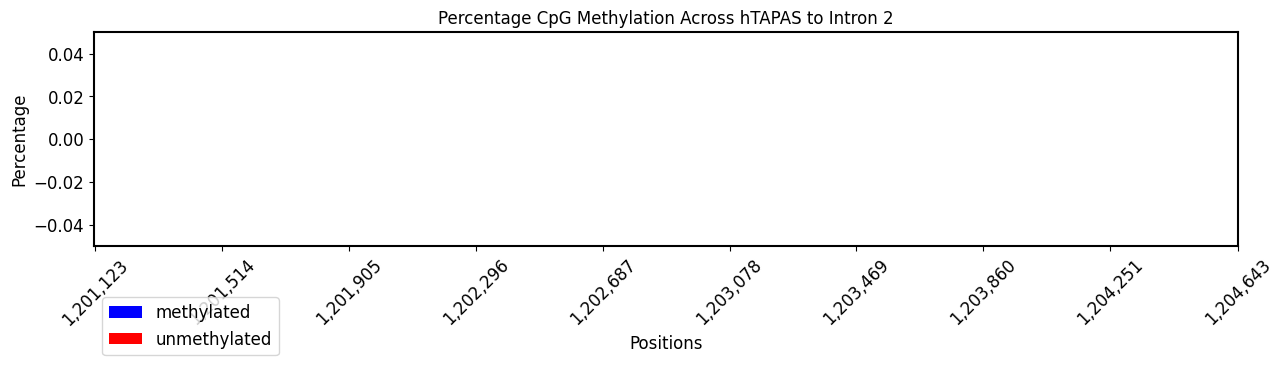

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode17.bam.aligned.bam.sorted.bam.bed


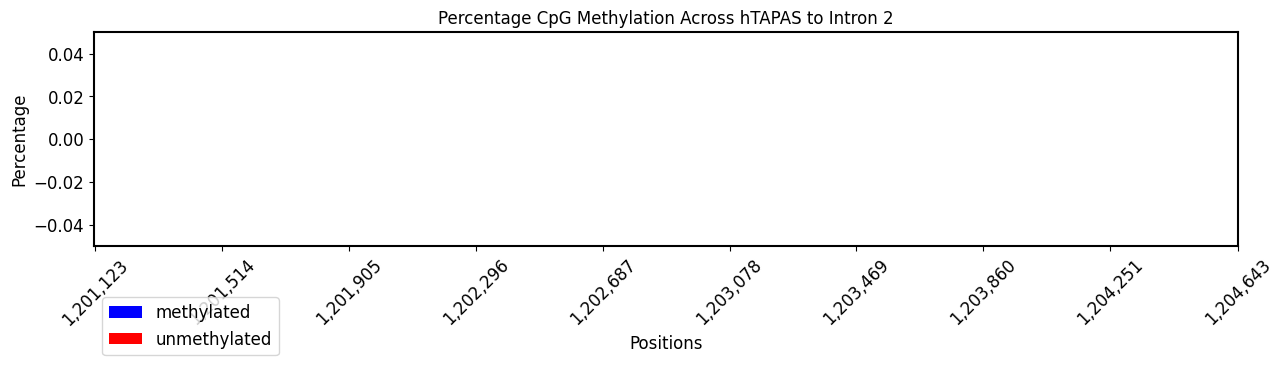

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode18.bam.aligned.bam.sorted.bam.bed


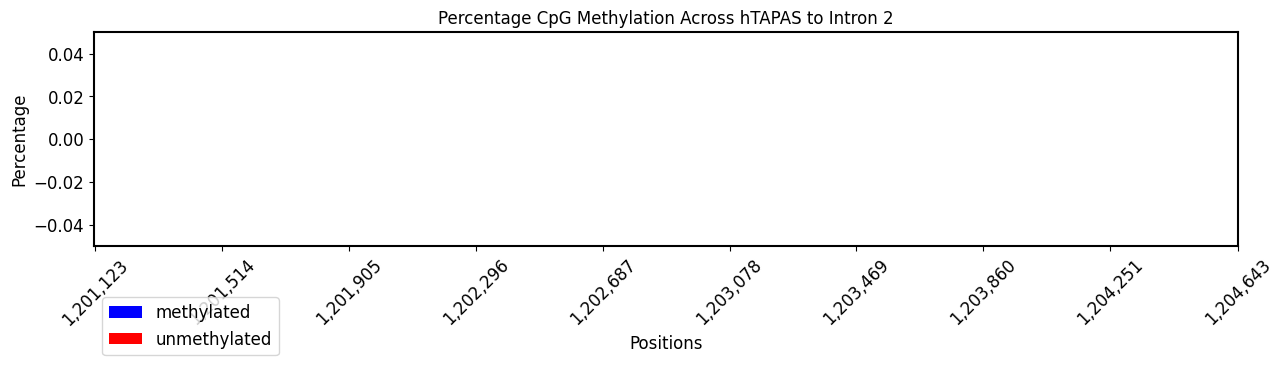

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode20.bam.aligned.bam.sorted.bam.bed


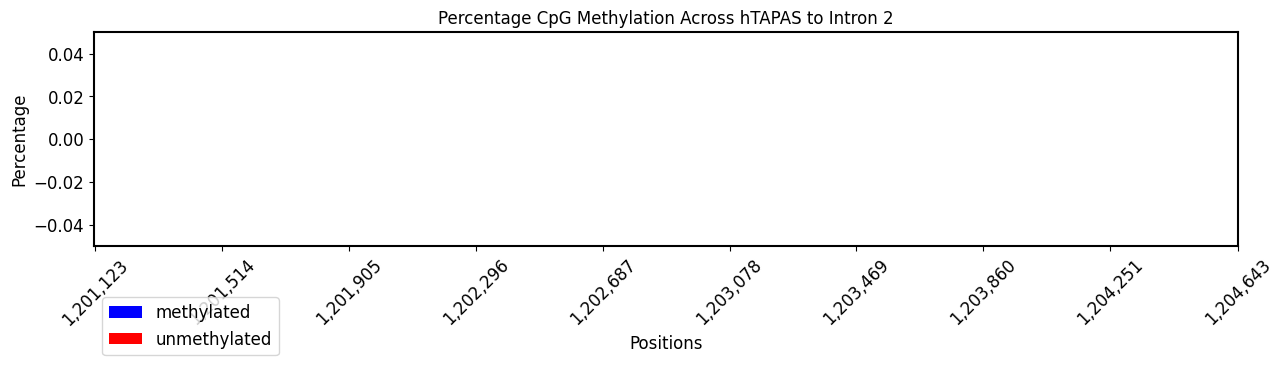

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode21.bam.aligned.bam.sorted.bam.bed


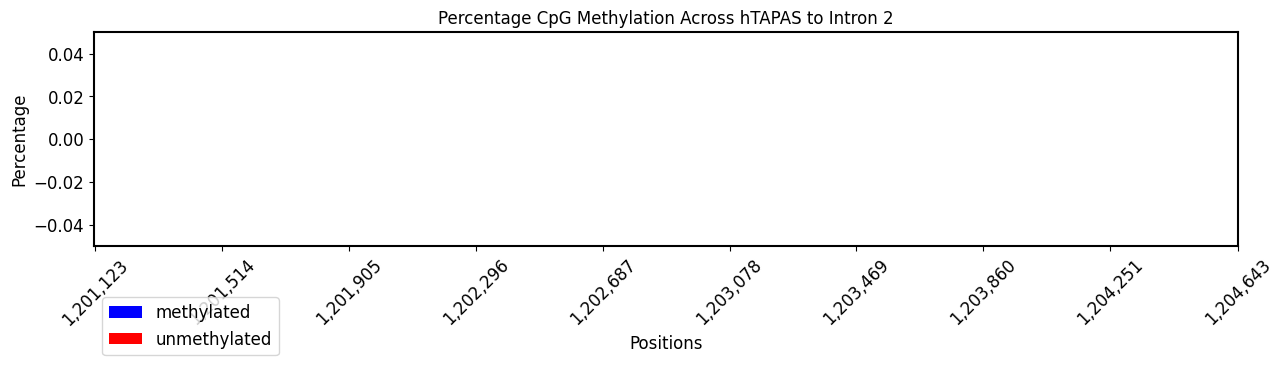

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


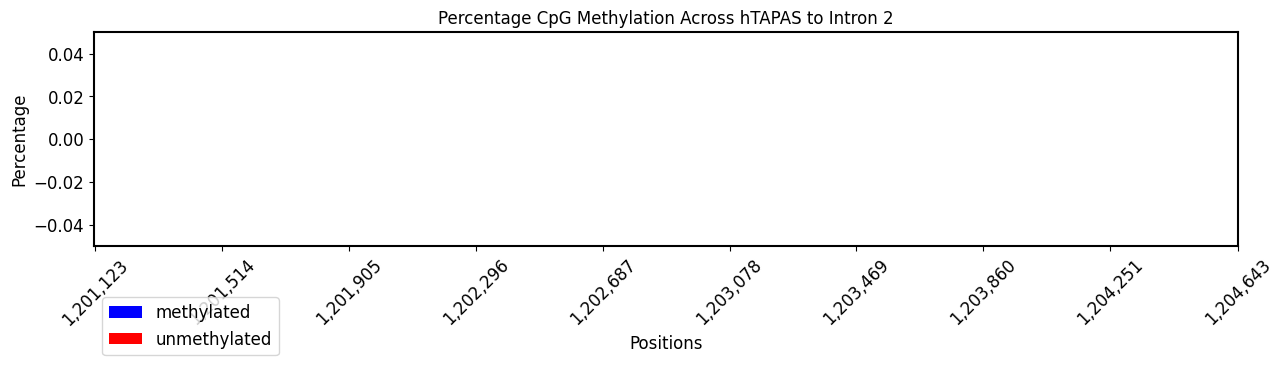

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


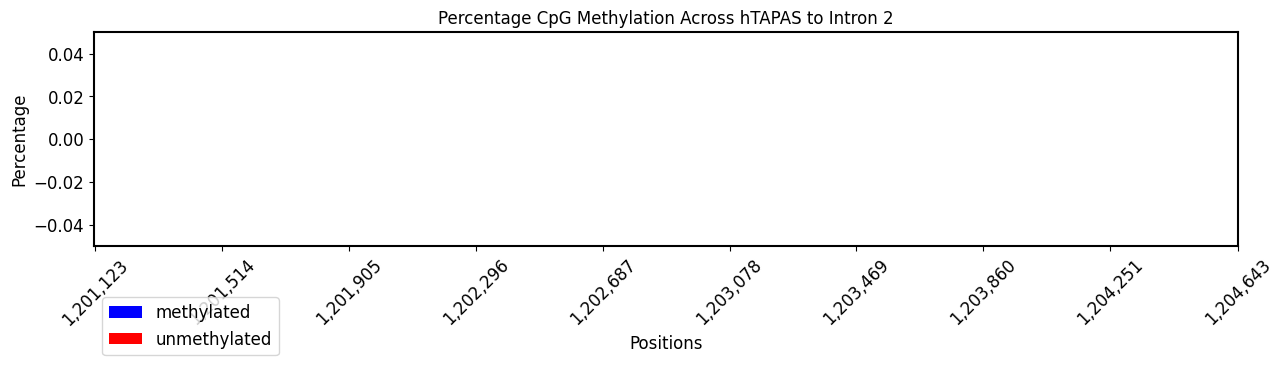

157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/88820a6847960d79af235156409c3a00a477d382_unclassified.bam.aligned.bam.sorted.bam.bed


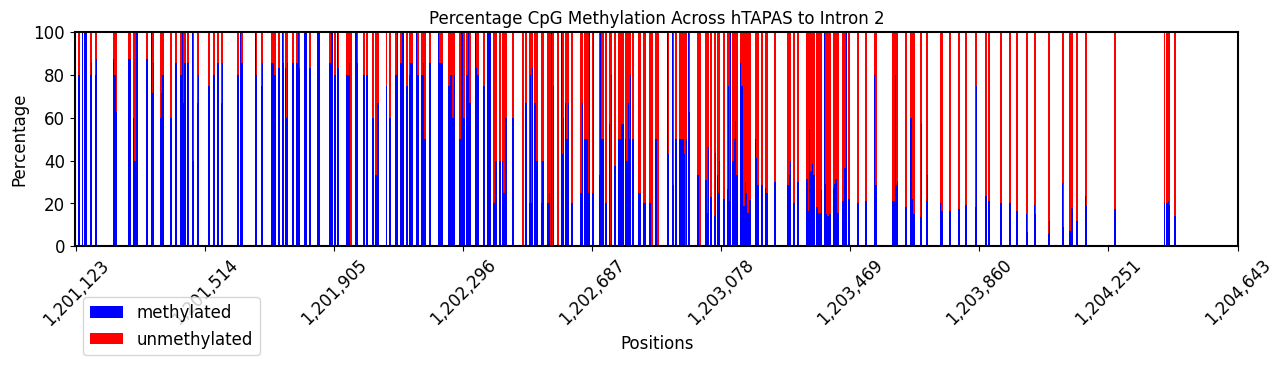

In [35]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmethZoom("157_LE_hTERT_HFF-1/T2T/DORADO_DEMUX/"+f,"157_"+f+"_Zoom_hTAPAS")

## Annotation

/tmp/ipykernel_1609279/829942186.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


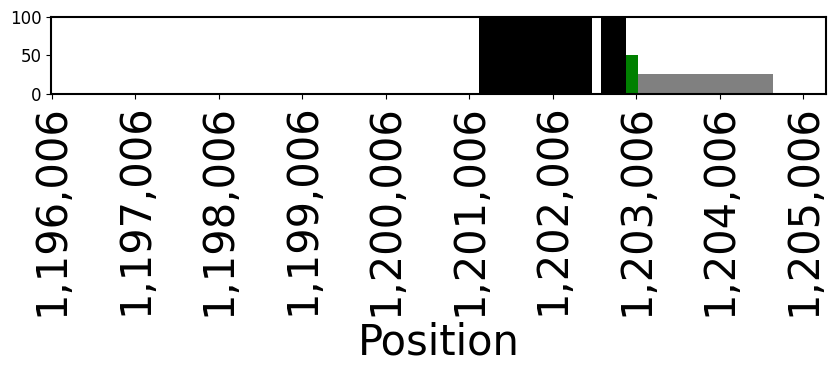

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

# Initialize annot dictionary
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa", "r")
annot = {}
count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count += 1
        annot[count] = 0
file.close()

# Define regions to color-code
for k, v in annot.items():
    if 1201123 <= k <= 1202476:
        annot[k] = 100
    elif 1202581 <= k <= 1202878:
        annot[k] = 100
    elif 1202862 <= k <= 1203024:
        annot[k] = 50
    elif 1203024 <= k <= 1204643:
        annot[k] = 25

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
#black_patch = mpatches.Patch(color='black', label='exon')
#green_patch = mpatches.Patch(color='green', label='core promoter')
#grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

#plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPASAnnotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()
